# Nano-ranking: NAIS data:

- we applying the nano-ranking 
- the nais data and dmps data is regridded 
- upscaled to 15 minutes

Figures:

- figureS13
- figureS14
- figureS15

In [1]:
import glob
import xarray as xr
from sklearn.linear_model import LinearRegression
import math
import datetime 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from xarray.plot.utils import _infer_interval_breaks as infer_interval_breaks
import pandas as pd
import matplotlib.dates as dts
from matplotlib.colors import LogNorm, Normalize
from scipy.ndimage.filters import gaussian_filter
from matplotlib.dates import DateFormatter
from datetime import timedelta
import re
import os
import matplotlib
from pathlib import Path
from scipy import stats
from scipy.optimize import curve_fit
import matplotlib as mpl
from scipy.stats import percentileofscore
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

plt.rcParams["font.family"] = 'monospace'

C:\Users\Dell\AppData\Local\Temp\ipykernel_19948\1886723112.py:13: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


In [2]:
# Define paths relative to notebook location
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

In [3]:
method_name='rate'
loadpath_GR_dfs=r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\GR_dfs'

df_NPF_for_hsplit = pd.read_csv(loadpath_GR_dfs+'\\'+'GR_'+str(method_name)+'.dat',
    index_col=0,parse_dates=True)

In [4]:
def from_Dp2lDp(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset,
xr.DataArray]:
    """
    Convert particle diameter to log10(particle diameter)

    Parameters
    ----------
    o : xr.Dataset
        Dataset with a 'Dp' variable

    Returns
    -------
    xr.Dataset
        Dataset with a 'lDp' variable added,
        where 'lDp' is the base-10 logarithm of 'Dp'.
    """
    lDp = np.log10(o['Dp'])
    o = o.assign_coords({'lDp': lDp})
    return o

def set_lDp(o):
    dims = list(o.dims)
    coords = list(o.coords)
    # o_coords = set(coords)-set(dims)
    if 'lDp' not in coords:
        o = from_Dp2lDp(o)
    if 'lDp' not in dims:
        o = o.swap_dims({'Dp': 'lDp'})
    return o

def dp_regrid(da, *, n_subs, log_dy):

    if isinstance(da, xr.DataArray):
        assert da.name == 'dndlDp'
        da_ = da
    elif isinstance(da, xr.Dataset):
        da_ = da['dndlDp']

    # Keep original time coordinate
    time = da_.time

    # Convert Dp -> lDp
    ds1 = set_lDp(da_).reset_coords(drop=True)

    # Fine-grid spacing
    dy = log_dy / n_subs

    # Original lDp interval boundaries
    ints = infer_interval_breaks(
        ds1['lDp'],
        check_monotonic=True
    )

    ym_ = float(ints[0])
    yM_ = float(ints[-1])

    # Align fine grid with dy
    ym = np.round(ym_ / dy) * dy
    yM = np.round(yM_ / dy) * dy

    # Fine lDp grid
    yl = np.arange(
        ym,
        yM + dy / 2,
        dy
    )

    # Interpolate
    d1 = ds1.interp(
        lDp=yl,
        kwargs=dict(fill_value="extrapolate")
    )

    # Number of complete output bins
    n_bins = len(yl) // n_subs

    # Discard incomplete final bin
    d1 = d1.isel(
        lDp=slice(0, n_bins * n_subs)
    )

    # ---------------------------------------------------------
    # Reshape:
    #
    # (time, fine_lDp)
    #
    #        ↓
    #
    # (time, lDp_bin, sub)
    # ---------------------------------------------------------

    values = d1.values.reshape(
        len(time),
        n_bins,
        n_subs
    )

    # Mean over subintervals
    values = values.mean(axis=2)

    # Output lDp coordinates
    lDp = (
        ym
        + (np.arange(n_bins) + 0.5) * log_dy
    )

    # Construct output explicitly
    dsout = xr.DataArray(
        values,
        dims=('time', 'lDp'),
        coords={
            'time': time,
            'lDp': lDp,
        },
        name='dndlDp',
        attrs=da_.attrs,
    )

    return dsout

def from_lDp2Dp(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset,
xr.DataArray]:
    """
    Convert log10(particle diameter) to particle diameter

    Parameters
    ----------
    o : xr.Dataset
        Dataset with a 'lDp' variable

    Returns
    -------
    xr.Dataset
        Dataset with a 'Dp' variable added,
        where 'Dp' is the base-10 exponential of 'lDp'.
    """
    Dp = 10 ** (o['lDp'])
    o = o.assign_coords({'Dp': Dp})
    return o


def set_sec(o):
    dims = list(o.dims)
    coords = list(o.coords)
    # o_coords = set(coords)-set(dims)
    if 'secs' not in coords:
        o = from_time2sec(o)
    if 'secs' not in dims:
        o = o.swap_dims({'time': 'secs'})
    return o

def from_sec2time(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset, xr.DataArray]:
    """
    Convert seconds since 1970-01-01 to time

    Parameters
    ----------
    o : Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'secs' coordinate

    Returns
    -------
    Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'time' coordinate added,
        where 'time' is the date and time corresponding to the
        number of seconds since 1970-01-01.
    """
    secs = o['secs'].astype('datetime64[s]')
    o = o.assign_coords({'time': secs})
    return o

def from_time2sec(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset, xr.DataArray]:
    """
    Convert time to seconds since 1970-01-01

    Parameters
    ----------
    o : Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'time' coordinate

    Returns
    -------
    Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'secs' coordinate added,
        where 'secs' is the time in seconds since 1970-01-01.
    """
    date = o['time']
    # handle numeric time coordinates (already seconds) or datetime64 with various units
    vals = date.values
    # numeric type: assume seconds since epoch already
    if np.issubdtype(vals.dtype, np.number):
        secs = vals.astype('float64')
    else:
        # try to compute seconds since UNIX epoch robustly
        try:
            epoch = np.datetime64('1970-01-01T00:00:00')
            secs = (vals - epoch) / np.timedelta64(1, 's')
        except Exception:
            # fallback: use pandas to_datetime then convert to seconds
            try:
                secs = pd.to_datetime(vals).astype('int64') / 1e9
            except Exception:
                # last resort: attempt matplotlib date2num then convert days to seconds
                try:
                    import matplotlib.dates as mdates
                    secs = (mdates.date2num(vals) - mdates.date2num(np.datetime64('1970-01-01'))) * 86400.0
                except Exception:
                    raise ValueError('Unsupported time coordinate dtype for from_time2sec: %s' % (vals.dtype,))

    # assign secs coordinate aligned with the time dimension
    o = o.assign_coords({'secs': (date.dims, secs)})
    return o

def set_time(o):
    dims = list(o.dims)
    coords = list(o.coords)
    # o_coords = set(coords)-set(dims)

    if 'time' not in coords:
        o = from_sec2time(o)

    if 'time' not in dims:
        o = o.swap_dims({'secs': 'time'})

    return o

def set_Dp(o):
    dims = list(o.dims)
    coords = list(o.coords)
    if 'Dp' not in coords:
        # print(coords)
        o = from_lDp2Dp(o)
    if 'Dp' not in dims:
        o = o.swap_dims({'lDp': 'Dp'})
    return o

def upsample_ts(o, dt):
    dt = float(dt)
    orgi_dt = set_sec(o)['secs'].diff('secs').mean().item()
    assert dt <= orgi_dt, 'you are trying to upsample when you should be downsampling'
    orig_dim = list(o.dims)
    print('original dims:', orig_dim)
    o = set_time(o)
    o = o.resample({'time': pd.Timedelta(dt, unit='s')}).interpolate('linear')
    if 'time' in orig_dim:
        o = set_time(o)
    if 'secs' in orig_dim:
        o = set_sec(o)
    return o

In [5]:
def thickax(ax, fontsize=12):
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.5)
    plt.rc('axes', linewidth=1.5)    
    ax = plt.gca()
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    ax.tick_params(direction='out', length=7, width=1.5, pad=12, bottom=True, top=False, left=True, right=False)
	
def spectral_plot(xr_nais, var, title, x='time', fs_label=15, xlabel='Datetime', log_colour_scale=True, add_axis_labels=True,
                  add_colourbar_labels=False, vmin=10**(-1), vmax=10**5, diameters_ticks=None,
                  cbar_label=r'dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', 
                  ylabel=r'D$_{\mathrm{p}}$ [m]', cmap='jet', xmin=None, xmax=None, 
                  remove_xticks=False, alpha=1, ax=None): #magma
    single_plot = False
    if ax == None:
        fig, ax = plt.subplots(figsize=(25,5))
        single_plot = True
        
    if log_colour_scale == True:
        xr_nais[var] = xr.where(xr_nais[var]==0, 10**(-100), xr_nais[var])    
        im = xr_nais[var].plot(x=x, yscale='log', norm=LogNorm(vmin=vmin,vmax=vmax), cmap=cmap, 
                                        add_colorbar=False, alpha=alpha, ax=ax)
    if log_colour_scale == False:
        im = xr_nais[var].plot(x=x, yscale='log', vmin=vmin, vmax=vmax, cmap=cmap, 
                                        add_colorbar=False, alpha=alpha, ax=ax)    
    if add_axis_labels == True:
        ax.set_ylabel(ylabel, fontsize=fs_label)
        ax.set_xlabel(xlabel, fontsize=fs_label)
        ax.set_title(title, fontsize=fs_label, loc='left')
    
    thickax(ax, fontsize=fs_label)
    ax.set_xlim(xmin, xmax)
    if remove_xticks == True:
        ax.set_xticklabels([])
       
    if add_colourbar_labels == True: 
        cb = plt.colorbar(im, orientation="vertical")
        cb.set_label(label=cbar_label, size=fs_label)
        cb.ax.tick_params(labelsize=fs_label)
    
    if single_plot == True:
        plt.show()
        return fig
    if single_plot == False:
        return ax

In [6]:
def rename_resample_xr(XR_resampled, polarity='neg', mode='particles', resolution='15T', 
                           average='median'):
    xr_nais = XR_resampled[str(polarity)+'_'+str(mode)].to_pandas()
    #resample to 15 minutes
    if average == 'mean':
        ds_ = xr_nais.stack().to_xarray().rename({'diameter':'Dp'}).assign_coords({'Dp':lambda d:d['Dp'].astype(float)}).rename('dndlDp').sortby('time').resample({'time':resolution}).mean()
    if average == 'median':
        ds_ = xr_nais.stack().to_xarray().rename({'diameter':'Dp'}).assign_coords({'Dp':lambda d:d['Dp'].astype(float)}).rename('dndlDp').sortby('time').resample({'time':resolution}).median()
    ds_.drop_duplicates(dim='time')
    return ds_

def regrid_ds(ds_):
    ## regridding ppsamples a time series with a given time step. Regrids the diameter distribution of 40 to 27
    ds = (ds_.pipe(dp_regrid, log_dy=.05, n_subs=10).pipe(set_Dp))    
    return ds

def interpolate_ds(ds, minutes=15):
    ds=ds.pipe(upsample_ts, dt=minutes*60) #linear interpolation
    ds = ds.to_dataset()
    return ds

In [7]:
########### LOAD 5 MINUTE NAIS DATA ####################################################################
resolution = '5min'
path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\resampled\resampled_removed_snow_clouds_bad_charged'
XR_resampled = xr.open_dataset(path+'\\'+str(resolution)+'_removed_snow_clouds_bad_charged.nc')
polarity='neg';
mode='particles'

In [8]:
########## REGRID AND INTERPOLATE 5 MINUTE NAIS DATA TO 15 MINUTES ####################################################################
ds_nais = rename_resample_xr(XR_resampled, polarity='neg', mode='particles', 
                             resolution='15min', average='median')

ds_nais = regrid_ds(ds_nais)
ds_nais =  interpolate_ds(ds_nais, minutes=15)

ds_nais = ds_nais.drop_vars('lDp')
print(ds_nais.dims)
print(ds_nais.Dp)

original dims: ['time', 'Dp']
FrozenMappingWarningOnValuesAccess({'Dp': 40, 'time': 86593})
<xarray.DataArray 'Dp' (Dp: 40)> Size: 320B
array([5.011872e-10, 5.623413e-10, 6.309573e-10, 7.079458e-10, 7.943282e-10,
       8.912509e-10, 1.000000e-09, 1.122018e-09, 1.258925e-09, 1.412538e-09,
       1.584893e-09, 1.778279e-09, 1.995262e-09, 2.238721e-09, 2.511886e-09,
       2.818383e-09, 3.162278e-09, 3.548134e-09, 3.981072e-09, 4.466836e-09,
       5.011872e-09, 5.623413e-09, 6.309573e-09, 7.079458e-09, 7.943282e-09,
       8.912509e-09, 1.000000e-08, 1.122018e-08, 1.258925e-08, 1.412538e-08,
       1.584893e-08, 1.778279e-08, 1.995262e-08, 2.238721e-08, 2.511886e-08,
       2.818383e-08, 3.162278e-08, 3.548134e-08, 3.981072e-08, 4.466836e-08])
Coordinates:
  * Dp       (Dp) float64 320B 5.012e-10 5.623e-10 ... 3.981e-08 4.467e-08


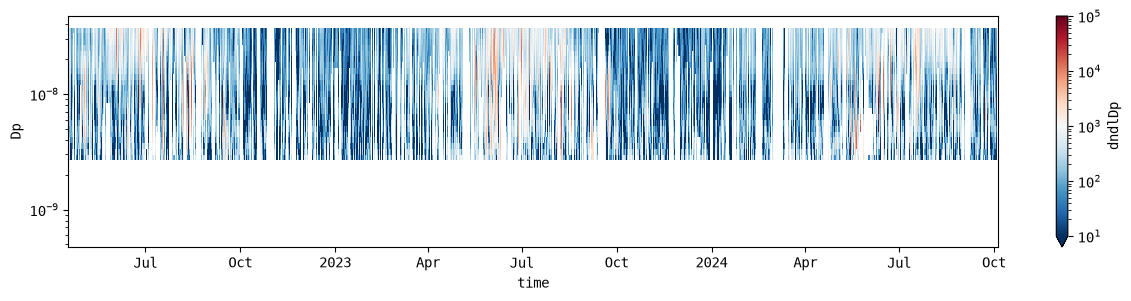

In [9]:
ds_nais['dndlDp'].plot(figsize=(15,3), x='time', y='Dp', yscale='log', 
                                 norm = LogNorm(vmin=1e1,vmax=1e5))

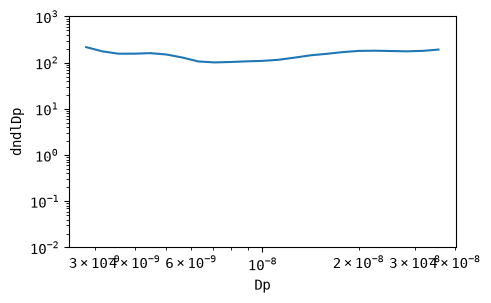

In [10]:
(ds_nais.median('time')['dndlDp'].plot(figsize=(5,3), hue='id',yscale='log',xscale='log'))
plt.ylim(10**(-2), 10**3)
plt.show()

In [11]:
ds_nais

<xarray.Dataset> Size: 28MB
Dimensions:  (Dp: 40, time: 86593)
Coordinates:
  * Dp       (Dp) float64 320B 5.012e-10 5.623e-10 ... 3.981e-08 4.467e-08
  * time     (time) datetime64[ns] 693kB 2022-04-17 ... 2024-10-05
Data variables:
    dndlDp   (time, Dp) float64 28MB nan nan nan nan nan ... nan nan nan nan nan

In [12]:
def save_nc_file(ds, save_folder, instrument, polarity='neg', mode='particles', average='median'):
    i = 1 #version number    
    #save
    if polarity == 'neg':
        polarity_name = 'np'
    if mode == 'particles':
        mode_name = 'par'
    if mode == 'ions':
        mode_name = 'ion'
    try:        
        file = str(polarity_name)+"_"+str(mode_name)+"_ZEP_"+str(instrument)+"_"+str(average)+'_v'+str(i)+".nc"       
        ds.to_netcdf(save_folder+'\\'+file) 
        print("saved: ")
        print(save_folder+'\\'+file)    
    except:
        i=i+1        
        file = str(polarity_name)+"_"+str(mode_name)+"_ZEP_"+str(instrument)+"_"+str(average)+'_v'+str(i)+".nc"      
        ds.to_netcdf(save_folder+'\\'+file) 
        print("saved: ")  
        print(save_folder+'\\'+file)     

In [13]:
polarity='neg';
mode='particles'

nanoranking_save_folder = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\resampled\resample_nanoranking'

save_nc_file(ds_nais, nanoranking_save_folder, instrument='nais', polarity='neg', mode='particles', average='median')

saved: 
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\resampled\resample_nanoranking\np_par_ZEP_nais_median_v1.nc


In [14]:
def unstack_day(ds):
    return (
        ds
        .assign_coords(t=(lambda d: d['time']))
        .assign_coords(day=(lambda d: d['time'].dt.floor('1D')))
        .assign_coords(
            hour=(lambda d: (d['time'] - d['day']) / pd.Timedelta('1h')))
        .set_index({'time': ['day', 'hour']})
        .unstack('time')
    )

In [15]:
ds2 = (ds_nais.pipe(unstack_day).assign_coords({'d':lambda d:xr.zeros_like(d['day'],dtype=int)+np.arange(len(d['day']))}).swap_dims({'day':'d'}))
days = ds2.d.values
print(days[-1])

902


## DMPS: 

In [16]:
#load DMPS data which has a resolution of 30 minutes

load_path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\dmps'
filename='DMPS_QC_2022_2024_30min.nc'
id_name='dmps'

xr_dmps_30min = xr.open_dataset(load_path+'\\'+filename)
df_dmps = xr_dmps_30min['dmps_number'].to_pandas()
diameters_m = list(df_dmps.columns)
print(diameters_m)

#rename and resample to 30 minuyes (should already be)
ds_dmps_ = df_dmps[diameters_m].stack().to_xarray().rename({'diameter':'Dp'}).assign_coords({'Dp':lambda d:d['Dp'].astype(float)}).rename('dndlDp').sortby('time').resample({'time':'30min'}).median()
#regrid 
ds_dmps = (ds_dmps_.pipe(dp_regrid, log_dy=.05, n_subs=10).pipe(set_Dp))

#seconds 15 minutes multipled by 60seconds = 900 seconds
ds_dmps=ds_dmps.pipe(upsample_ts, dt=15*60) 

ds_dmps = ds_dmps.to_dataset()
ds_dmps = ds_dmps.drop_vars('lDp')

print(ds_dmps.dims)
print(ds_dmps.Dp)

[5.012e-09, 5.623000000000001e-09, 6.31e-09, 7.079e-09, 7.943e-09, 8.913e-09, 1e-08, 1.122e-08, 1.2589000000000001e-08, 1.4125e-08, 1.5849000000000002e-08, 1.7783e-08, 1.9953e-08, 2.2387e-08, 2.5119e-08, 2.8184000000000003e-08, 3.1623000000000005e-08, 3.5481000000000005e-08, 3.9811000000000005e-08, 4.4668e-08, 5.0119e-08, 5.6234000000000006e-08, 6.3096e-08, 7.0795e-08, 7.943300000000001e-08, 8.9125e-08, 1.0000000000000001e-07, 1.12202e-07, 1.25893e-07, 1.41254e-07, 1.58489e-07, 1.7782800000000002e-07, 1.9952600000000004e-07, 2.2387200000000003e-07, 2.51189e-07, 2.8183800000000004e-07, 3.16228e-07, 3.54813e-07, 3.9810700000000003e-07, 4.4668400000000003e-07, 5.01187e-07, 5.623410000000001e-07, 6.309570000000001e-07, 7.07946e-07]
original dims: ['time', 'Dp']
FrozenMappingWarningOnValuesAccess({'Dp': 44, 'time': 131243})
<xarray.DataArray 'Dp' (Dp: 44)> Size: 352B
array([5.011872e-09, 5.623413e-09, 6.309573e-09, 7.079458e-09, 7.943282e-09,
       8.912509e-09, 1.000000e-08, 1.122018e-08,

In [17]:
ds_dmps

<xarray.Dataset> Size: 47MB
Dimensions:  (Dp: 44, time: 131243)
Coordinates:
  * Dp       (Dp) float64 352B 5.012e-09 5.623e-09 ... 6.31e-07 7.079e-07
  * time     (time) datetime64[ns] 1MB 2021-01-01 ... 2024-09-29T02:30:00
Data variables:
    dndlDp   (time, Dp) float64 46MB 5.124e-29 5.12e-29 ... 1.702e-29 1.672e-29

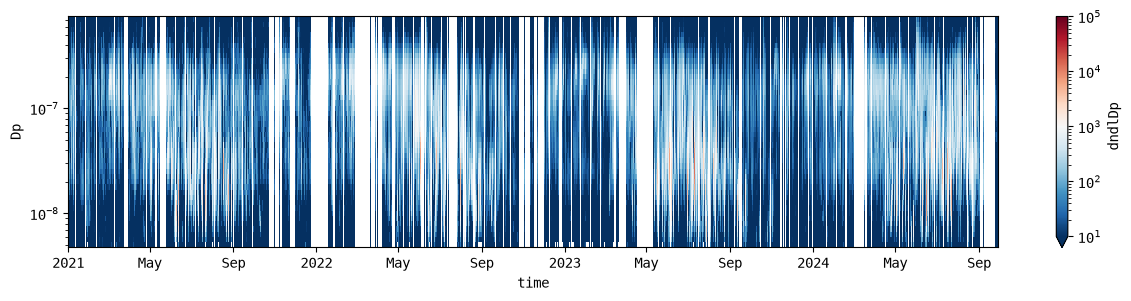

In [18]:
ds_dmps['dndlDp'].plot(figsize=(15,3), x='time', y='Dp', yscale='log', norm = LogNorm(vmin=1e1,vmax=1e5))

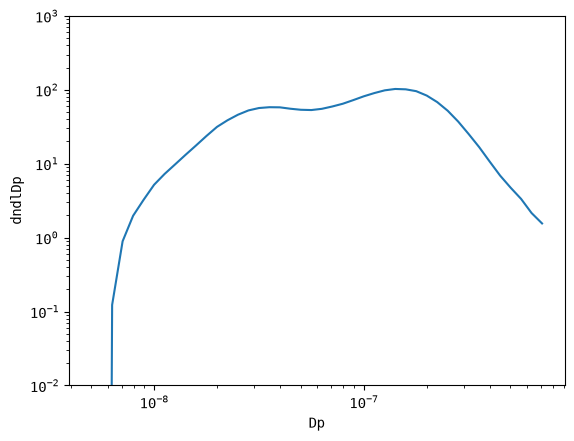

In [19]:
(ds_dmps.median('time')['dndlDp'].plot(hue='id',yscale='log',xscale='log'))
plt.ylim(10**(-2), 10**3)
plt.show()

In [20]:
save_nc_file(ds_dmps, nanoranking_save_folder, instrument='dmps', polarity='neg', 
             mode='particles', average='median')

saved: 
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\resampled\resample_nanoranking\np_par_ZEP_dmps_median_v1.nc


## Merge the two xarrays: 

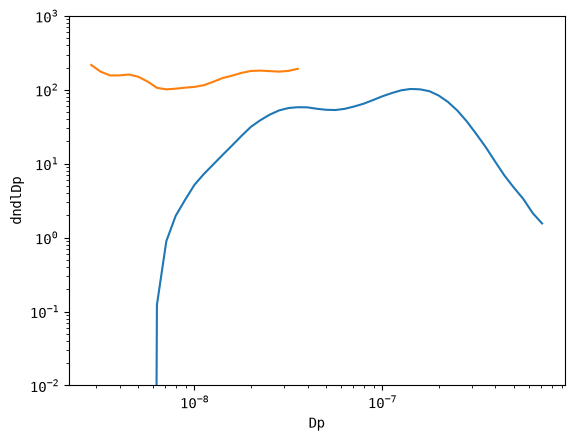

In [21]:
fig, ax = plt.subplots()

(ds_dmps.median('time')['dndlDp'].plot(yscale='log',xscale='log', ax=ax))

(ds_nais.median('time')['dndlDp'].plot(yscale='log',xscale='log', ax=ax))

plt.ylim(10**(-2), 10**3)
plt.show()

In [22]:
#The reason np.intersect1d() returned 0 is almost certainly floating-point representation: the printed values look identical, but the underlying floats differ by tiny amounts.

print("NAIS Dp:", len(ds_nais.Dp))
print("DMPS Dp:", len(ds_dmps.Dp))

print("NAIS unique:", len(np.unique(ds_nais.Dp.values)))
print("DMPS unique:", len(np.unique(ds_dmps.Dp.values)))

print("overlap:",
      len(np.intersect1d(
          ds_nais.Dp.values,
          ds_dmps.Dp.values
      )))

print("union:",
      len(np.union1d(
          ds_nais.Dp.values,
          ds_dmps.Dp.values
      )))

NAIS Dp: 40
DMPS Dp: 44
NAIS unique: 40
DMPS unique: 44
overlap: 0
union: 84


In [23]:
def clean_dp(ds):
    log_dp = np.log10(ds.Dp.values)
    # Round log10(Dp) to remove floating-point noise
    log_dp = np.round(log_dp, 10)
    return ds.assign_coords(Dp=10 ** log_dp)

ds_nais = clean_dp(ds_nais)
ds_dmps = clean_dp(ds_dmps)

In [24]:
#The reason np.intersect1d() returned 0 is almost certainly floating-point representation: the printed values look identical, but the underlying floats differ by tiny amounts.

print("NAIS Dp:", len(ds_nais.Dp))
print("DMPS Dp:", len(ds_dmps.Dp))

print("NAIS unique:", len(np.unique(ds_nais.Dp.values)))
print("DMPS unique:", len(np.unique(ds_dmps.Dp.values)))

print("overlap:",
      len(np.intersect1d(
          ds_nais.Dp.values,
          ds_dmps.Dp.values
      )))

print("union:",
      len(np.union1d(
          ds_nais.Dp.values,
          ds_dmps.Dp.values
      )))

NAIS Dp: 40
DMPS Dp: 44
NAIS unique: 40
DMPS unique: 44
overlap: 20
union: 64


In [25]:
print(ds_nais.Dp.values)
print(ds_dmps.Dp.values)

[5.01187234e-10 5.62341325e-10 6.30957344e-10 7.07945784e-10
 7.94328235e-10 8.91250938e-10 1.00000000e-09 1.12201845e-09
 1.25892541e-09 1.41253754e-09 1.58489319e-09 1.77827941e-09
 1.99526231e-09 2.23872114e-09 2.51188643e-09 2.81838293e-09
 3.16227766e-09 3.54813389e-09 3.98107171e-09 4.46683592e-09
 5.01187234e-09 5.62341325e-09 6.30957344e-09 7.07945784e-09
 7.94328235e-09 8.91250938e-09 1.00000000e-08 1.12201845e-08
 1.25892541e-08 1.41253754e-08 1.58489319e-08 1.77827941e-08
 1.99526231e-08 2.23872114e-08 2.51188643e-08 2.81838293e-08
 3.16227766e-08 3.54813389e-08 3.98107171e-08 4.46683592e-08]
[5.01187234e-09 5.62341325e-09 6.30957344e-09 7.07945784e-09
 7.94328235e-09 8.91250938e-09 1.00000000e-08 1.12201845e-08
 1.25892541e-08 1.41253754e-08 1.58489319e-08 1.77827941e-08
 1.99526231e-08 2.23872114e-08 2.51188643e-08 2.81838293e-08
 3.16227766e-08 3.54813389e-08 3.98107171e-08 4.46683592e-08
 5.01187234e-08 5.62341325e-08 6.30957344e-08 7.07945784e-08
 7.94328235e-08 8.91250

In [26]:
d1 = xr.concat(
    [
        ds_nais.expand_dims(id=["nais"]),
        ds_dmps.expand_dims(id=["dmps"])
    ],
    dim="id", join="outer"
)

In [27]:
d1.dims

FrozenMappingWarningOnValuesAccess({'id': 2, 'time': 131809, 'Dp': 64})

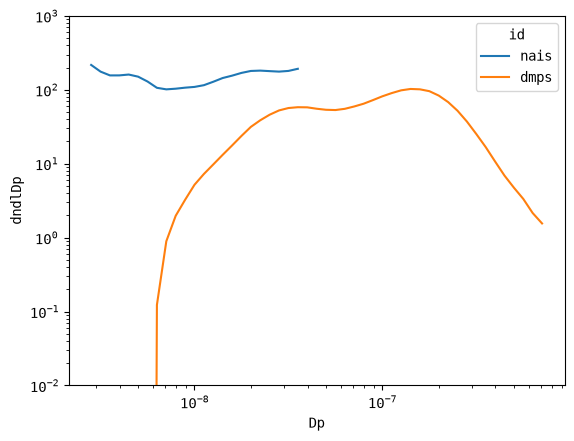

In [28]:
(d1.median('time')['dndlDp'].plot(hue='id',yscale='log',xscale='log'))
plt.ylim(10**(-2), 10**3)
plt.show()

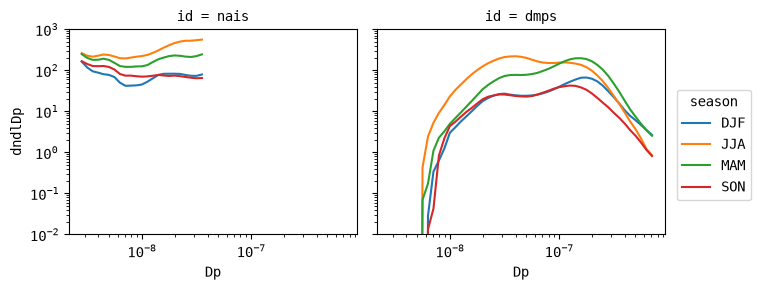

In [29]:
(d1.assign({'season':lambda d:d['time'].dt.season})
    .groupby('season')
    .median('time')
    ['dndlDp']
    .plot(
        hue='season',
        col='id',
        yscale='log',
        xscale='log'
    )
)
plt.ylim(10**(-2), 10**3)
plt.show()

# Load: 

In [30]:
def get_version_number(path, string_to_remove):
    """
    Remove `string_to_remove` from `path` and return the digit(s)
    that come immediately after the letter 'v'.

    Example:
        path = "/data/my_file_test_v12.nc"
        string_to_remove = "test_"

        returns: 12
    """
    cleaned_path = path.replace(string_to_remove, "")

    match = re.search(r"v(\d+)", cleaned_path)

    if match:
        return int(match.group(1))

    raise ValueError(f"No version number found after 'v' in: {cleaned_path}")

def latest_version(files):
    if len(files) > 1:
        versions = []
        for file_ in files:
            version = get_version_number(file_, load_path)
            versions.append(version)
        print(versions)
        latest_v = max(versions)
        print(latest_v)
    if len(files) == 1:
        latest_v = 1
    return latest_v

In [31]:
load_path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\resampled\resample_nanoranking'

nais_files = glob.glob(load_path+'\\*_nais_*')
dmps_files = glob.glob(load_path+'\\*_dmps_*')

print(nais_files)
print(dmps_files)

latest_v = latest_version(nais_files)
nais_file = glob.glob(load_path+'\\*nais*v'+str(latest_v)+'*')
print(nais_file)

latest_v = latest_version(dmps_files)
dmps_file = glob.glob(load_path+'\\*dmps*v'+str(latest_v)+'*')
print(dmps_file)

load = False

if load == True:
    print(nais_file)
    dn = (xr.open_dataset(nais_file))
    ds = (xr.open_dataset(dmps_file)) 
if load == False:
    dn = ds_nais.copy()
    ds = ds_dmps.copy()  


['C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\resampled\\resample_nanoranking\\np_par_ZEP_nais_median_v1.nc']
['C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\resampled\\resample_nanoranking\\np_par_ZEP_dmps_median_v1.nc']
['C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\resampled\\resample_nanoranking\\np_par_ZEP_nais_median_v1.nc']
['C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\resampled\\resample_nanoranking\\np_par_ZEP_dmps_median_v1.nc']


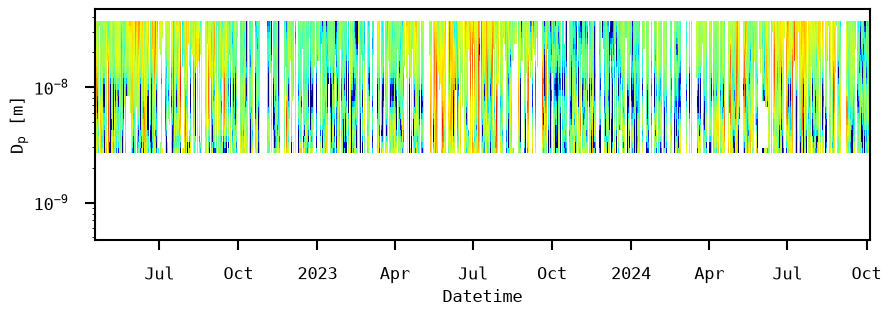

In [32]:
fig, ax = plt.subplots(figsize=(10, 3))
spectral_plot(ds_nais, var='dndlDp', fs_label=12, x='time', title='', ax=ax)
plt.show()

In [33]:
def get_nais_dmps(d):
    d1 = d[['dndlDp']].loc[{'id':'nais','Dp':slice(0,2.e-8)}]
    d2 = d[['dndlDp']].loc[{'id':'dmps','Dp':slice(2.e-8+.00001e-8,1)}]*2
    dc = xr.concat([d1, d2], dim='Dp')
    dc['id'] = 'nd'
    dcc = xr.concat([d,dc],dim='id')
    return dcc

In [34]:
ds_N = d1.pipe(get_nais_dmps)

C:\Users\Dell\AppData\Local\Temp\ipykernel_19948\510537688.py:4: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  dc = xr.concat([d1, d2], dim='Dp')


In [35]:
ds_N

<xarray.Dataset> Size: 204MB
Dimensions:  (id: 3, time: 131809, Dp: 64)
Coordinates:
  * id       (id) object 24B 'nais' 'dmps' 'nd'
  * time     (time) datetime64[ns] 1MB 2021-01-01 ... 2024-10-05
  * Dp       (Dp) float64 512B 5.012e-10 5.623e-10 ... 6.31e-07 7.079e-07
Data variables:
    dndlDp   (id, time, Dp) float64 202MB nan nan nan nan ... nan nan nan nan

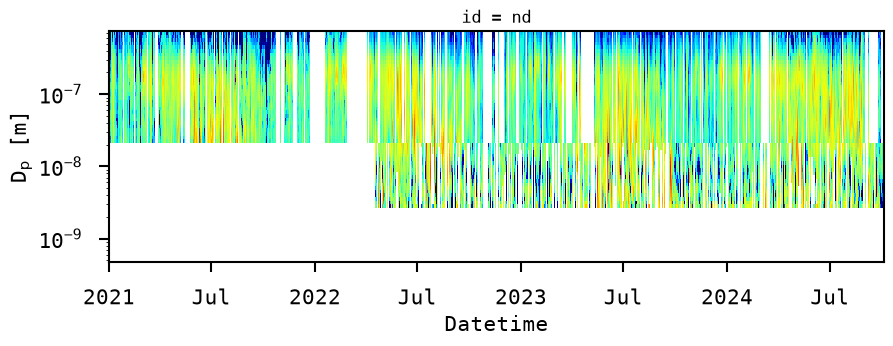

In [36]:
fig, ax = plt.subplots(figsize=(10, 3))
spectral_plot(ds_N.loc[{'id':'nd'}], var='dndlDp', x='time', title='', ax=ax)
#ax.set_xlim(pd.to_datetime('2024-01-21'), pd.to_datetime('2024-01-22'))
plt.show()

# Intensity parameter

Chose the intensity factor:

ie. get the total number concentration between 2.82 and 5 nm:

In [37]:
def get_exact_N(dc1, Dp_min, Dp_max):
    """
    Counts the exact number of particles in the range Dp_min to Dp_max using linear integration.

    Parameters
    ----------
    dc1 : xr.DataArray
        Array-like variable containing the number distribution function with log-normal diameter.
    Dp_min : float
        Minimum diameter in meters for which particle number is to be calculated.
    Dp_max : float
        Maximum diameter in meters for which particle number is to be calculated.

    Returns
    -------
    xr.DataArray
        Array-like variable containing the exact number of particles in the specified diameter range.
    """
    assert dc1.name == 'dndlDp', 'you can only calc N on dndlogDp'
    assert Dp_min < Dp_max, 'd1 not < d2'
    dc1_ = set_lDp(dc1)
    _breaks = infer_interval_breaks(dc1_['lDp'])
    lDp1 = _breaks[0]
    lDp2 = _breaks[-1]
    ld1 = np.log10(Dp_min)
    ld2 = np.log10(Dp_max)
    assert ld1 >= lDp1
    assert ld2 <= lDp2
    orig_dis = dc1_['lDp'].diff('lDp').median().item()
    print(orig_dis)
    new_full_dis = ld2 - ld1
    print(new_full_dis)
    dis = np.min([orig_dis, new_full_dis])
    dis_i = int(np.ceil(new_full_dis / dis) * 2)
    new_ld_list = np.linspace(ld1, ld2, dis_i)
    new_arr = dc1_.interp({'lDp': new_ld_list}, method='linear')
    new_inte = set_Dp(new_arr).integrate('lDp')
    new_inte = new_inte.expand_dims({'Dp_interval': [pd.Interval(Dp_min,Dp_max)]})
    new_inte.name = 'N'
    return new_inte

In [38]:
min_dp = 2.82 #nm
max_dp = 5 #nm

ds_N = d1.pipe(get_nais_dmps).assign({'N':lambda d:get_exact_N(d.loc[{'id':'nais'}]['dndlDp'],min_dp*10**(-9),
                                                                  max_dp*10**(-9))})

C:\Users\Dell\AppData\Local\Temp\ipykernel_19948\510537688.py:4: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  dc = xr.concat([d1, d2], dim='Dp')


0.04999999999999982
0.24872089601665692


In [39]:
ds_N

<xarray.Dataset> Size: 205MB
Dimensions:      (id: 3, time: 131809, Dp: 64, Dp_interval: 1)
Coordinates:
  * id           (id) object 24B 'nais' 'dmps' 'nd'
  * time         (time) datetime64[ns] 1MB 2021-01-01 ... 2024-10-05
  * Dp           (Dp) float64 512B 5.012e-10 5.623e-10 ... 6.31e-07 7.079e-07
  * Dp_interval  (Dp_interval) interval[float64, right] 16B (2.82e-09, 5e-09]
Data variables:
    dndlDp       (id, time, Dp) float64 202MB nan nan nan nan ... nan nan nan
    N            (Dp_interval, time) float64 1MB nan nan nan nan ... nan nan nan

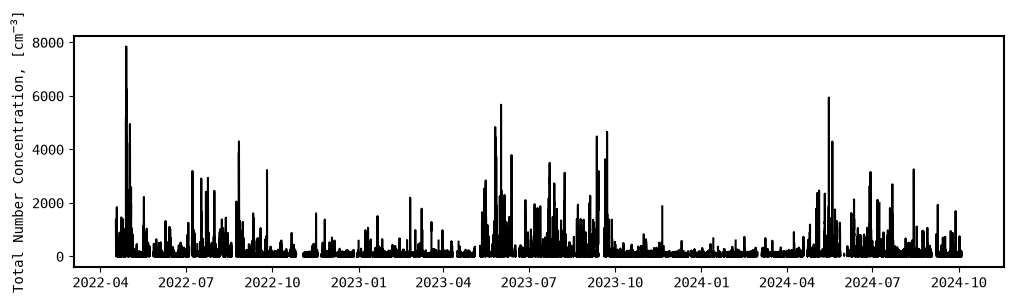

In [40]:
fig, ax = plt.subplots(1,1, figsize=(12,3))
ax.plot(ds_N['time'].values, ds_N['N'].values[0], ms=1, c='k')
ax.set_ylabel('Total Number Concentration, [cm$^{-3}$]')
plt.show()

# Log N: 

In [41]:
dp = ds_N['Dp'].values

print("minimum Dp:", np.nanmin(dp))
print("invalid Dp:", dp[~np.isfinite(dp) | (dp <= 0)])

ds_N_logged = ds_N.assign({'lN':lambda d:np.log10(d['N'])})

minimum Dp: 5.011872336272714e-10
invalid Dp: []


c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\.venv-2025-11-ms-code\Lib\site-packages\xarray\computation\apply_ufunc.py:820: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


In [42]:
ds_N_logged

<xarray.Dataset> Size: 206MB
Dimensions:      (id: 3, time: 131809, Dp: 64, Dp_interval: 1)
Coordinates:
  * id           (id) object 24B 'nais' 'dmps' 'nd'
  * time         (time) datetime64[ns] 1MB 2021-01-01 ... 2024-10-05
  * Dp           (Dp) float64 512B 5.012e-10 5.623e-10 ... 6.31e-07 7.079e-07
  * Dp_interval  (Dp_interval) interval[float64, right] 16B (2.82e-09, 5e-09]
Data variables:
    dndlDp       (id, time, Dp) float64 202MB nan nan nan nan ... nan nan nan
    N            (Dp_interval, time) float64 1MB nan nan nan nan ... nan nan nan
    lN           (Dp_interval, time) float64 1MB nan nan nan nan ... nan nan nan

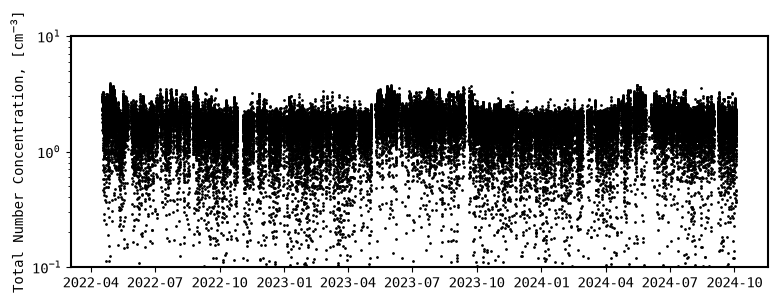

In [43]:
fig, ax = plt.subplots(1,1, figsize=(9,3))
ax.plot(ds_N_logged['time'].values, ds_N_logged['lN'].values[0], ms=1, c='k', marker='o', lw=0)
ax.set_yscale('log')
ax.set_ylabel('Total Number Concentration, [cm$^{-3}$]')
ax.set_ylim(10**(-1), 10**(1))
plt.show()

## Rolling means

In [44]:
ds_N_logged_rollin = (ds_N_logged.assign({'N_int_rollmed':lambda d: d['N'].rolling({'time':25},
                                                                                   min_periods=12,
                                                                                   center=True).median()}))

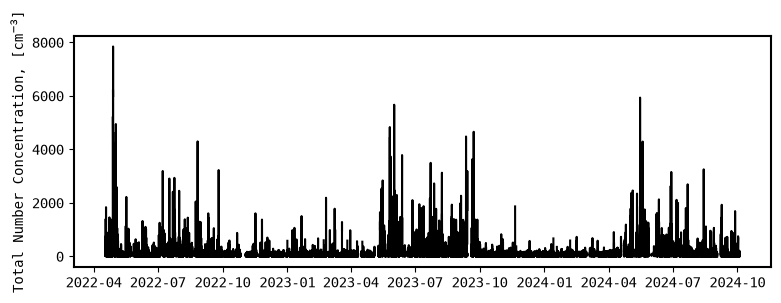

In [45]:
fig, ax = plt.subplots(1,1, figsize=(9,3))
ax.plot(ds_N_logged_rollin['time'].values, ds_N_logged_rollin['N'].values[0], ms=1, c='k')
ax.set_ylabel('Total Number Concentration, [cm$^{-3}$]')
plt.show()

In [46]:
ds_N_logged_rollin_dayadded =  unstack_day(ds_N_logged_rollin)

In [47]:
ds_rollinN_day_max = ds_N_logged_rollin_dayadded.assign({'N_int_max':lambda d:d['N_int_rollmed'].max('hour')})

# Max daily N int

C:\Users\Dell\AppData\Local\Temp\ipykernel_19948\4128444023.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


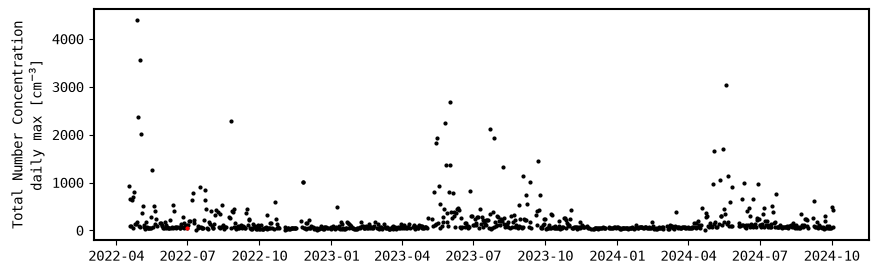

In [48]:
fig, ax = plt.subplots(1,1, figsize=(10,3))
ax.plot(ds_rollinN_day_max['day'].values, ds_rollinN_day_max['N_int_max'].values[0], 'o', ms=2, c='k')
ax.set_ylabel('Total Number Concentration\ndaily max [cm$^{-3}$]')

example_day = ds_rollinN_day_max.sel({'day':'2022-07-01'}).copy()

ax.plot(example_day['day'].values, example_day['N_int_max'].values[0], 'o', ms=2, c='r')
ax.legend(frameon=False)
plt.show()

In [49]:
ds_rollinN_day_max_percentiles = (ds_rollinN_day_max.assign({'N_90perc':lambda d:d['N_int_rollmed'].quantile(0.9, dim='hour')})
                        .assign({'N_20perc':lambda d:d['N_int_rollmed'].quantile(0.2, dim='hour')}))
ds_rollinN_day_max_percentiles['N_90-20']=ds_rollinN_day_max_percentiles['N_90perc']-ds_rollinN_day_max_percentiles['N_20perc']
ds_rollinN_day_max_percentiles['N_90/20']=ds_rollinN_day_max_percentiles['N_90perc']/ds_rollinN_day_max_percentiles['N_20perc']

ds_rollinN_day_max_percentiles['N_int_max'].where(ds_rollinN_day_max_percentiles['N_int_max']==ds_rollinN_day_max_percentiles['N_int_max'].max(), drop=True).squeeze()


c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\.venv-2025-11-ms-code\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


<xarray.DataArray 'N_int_max' ()> Size: 8B
array(4397.73290051)
Coordinates:
    day          datetime64[ns] 8B 2022-04-28
    Dp_interval  object 8B (2.82e-09, 5e-09]
    quantile     float64 8B 0.9

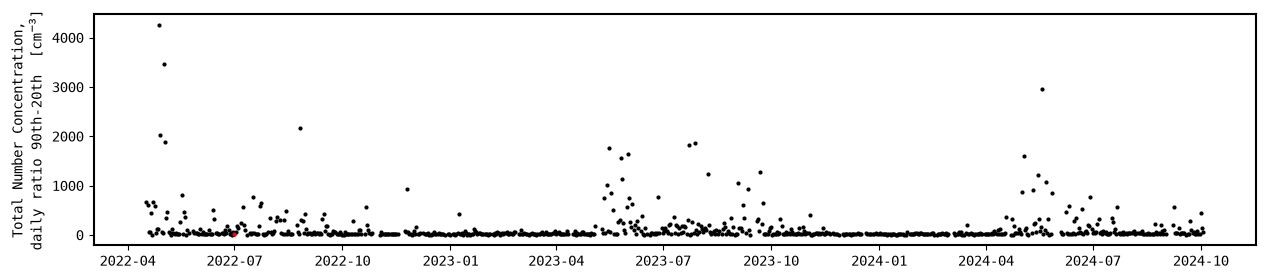

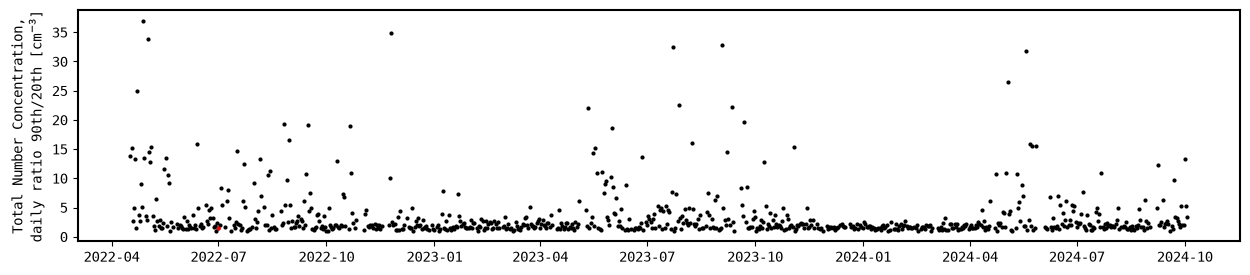

In [50]:
fig, ax = plt.subplots(1,1, figsize=(15,3))
ax.plot(ds_rollinN_day_max_percentiles['day'].values, ds_rollinN_day_max_percentiles['N_90-20'].values[0], 'o', ms=2, c='k')
ax.set_ylabel('Total Number Concentration,\ndaily ratio 90th-20th  [cm$^{-3}$]')

example_day = ds_rollinN_day_max_percentiles.sel({'day':'2022-07-01'}).copy()

ax.plot(example_day['day'].values, example_day['N_90-20'].values[0], 'o', ms=2, c='r', label='example daily max')
plt.show()


fig, ax = plt.subplots(1,1, figsize=(15,3))
ax.plot(ds_rollinN_day_max_percentiles['day'].values, ds_rollinN_day_max_percentiles['N_90/20'].values[0], 'o', ms=2, c='k')
ax.set_ylabel('Total Number Concentration,\ndaily ratio 90th/20th [cm$^{-3}$]')

example_day = ds_rollinN_day_max_percentiles.sel({'day':'2022-07-01'}).copy()

ax.plot(example_day['day'].values, example_day['N_90/20'].values[0], 'o', ms=2, c='r', label='example daily max')
plt.show()

In [51]:
def quick_density_plot(ds, intensity='N_90/20'):
    sns.kdeplot(
        data = ds[intensity].to_series(),
        bw_adjust=.98,
        clip=(ds[intensity].to_series().min(),
              ds[intensity].to_series().max())
    )
    ax:plt.Axes = plt.gca()
    plt.show()

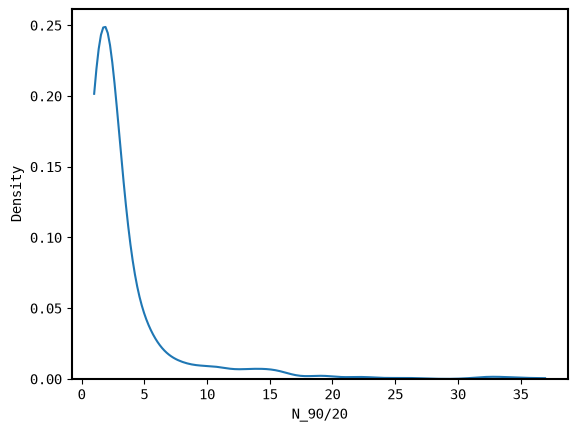

In [52]:
quick_density_plot(ds_rollinN_day_max_percentiles, intensity='N_90/20')

In [53]:
def log_intensity(d, var_to_log='N_90/20'):
    d_ = (d.assign({'d_'+str(var_to_log):lambda d:np.log10(d[var_to_log])}))
    return d_

In [54]:
ds_rollinN_day_max_percentiles_logged = log_intensity(ds_rollinN_day_max_percentiles)

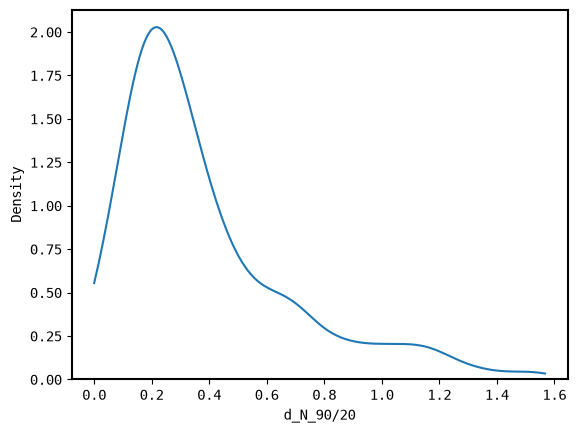

In [55]:
quick_density_plot(ds_rollinN_day_max_percentiles_logged, intensity='d_N_90/20')

In [56]:
def gaussian(x, amplitude, mean, stddev):
    return amplitude * np.exp(-(x - mean) ** 2 / 2 / stddev ** 2)


# Define three-Gaussian function
def three_gaussians(x, *m):
    return (
            gaussian(x, m[0], m[1], m[2]) +
            gaussian(x, m[3], m[4], m[5]) +
            gaussian(x, m[6], m[7], m[8])
    )


def fit_gaussians(logn, mi, ma, A, B, C, bw):
    """
    Fits three Gaussians to the logn distribution and calculates m12 and m23.

    Parameters:
        logn (array-like): An array of values representing the distribution.
        mi (float): The minimum value for the x-axis.
        ma (float): The maximum value for the x-axis.

    Returns:
        Tuple of two floats: m12 and m23.
    """

    # Estimate kernel density function
    kern = stats.gaussian_kde(logn, bw_method=bw)

    # Generate x and y values for plotting
    x = np.linspace(mi, ma, 200)
    y = kern(x)

    # Fit three Gaussians to the data
    res = curve_fit(
        three_gaussians, x, y, p0=A,
        bounds=(B, C)
        )

    (a1, c1, s1, a2, c2, s2, a3, c3, s3,) = res[0]

    # Calculate m12 and m23
    c12 = (c1 + c2) / 2
    c23 = (c2 + c3) / 2

    # Plot the results
    plt.plot(x, three_gaussians(x, *res[0]), label='fit', lw=2, ls='--',alpha=.5, c='C0')
    plt.plot(x, gaussian(x, a1, c1, s1, ), label='g1',c='C1')
    plt.plot(x, gaussian(x, a2, c2, s2, ), label='g2',c='C2')
    plt.plot(x, gaussian(x, a3, c3, s3, ), label='g3',c='C4')
    # plt.plot(x, y, label='KDE')
    plt.axvline(c12, label='(c1 + c2) / 2', c='k', ls=':',alpha=.5)
    plt.axvline(c23, label='(c2 + c3) / 2', c='k', ls=':',alpha=.5)

    plt.legend()
    # Return m12 and m23
    return c12, c23, res[0]

In [57]:
def fit_gaussians(logn, mi, ma, A, B, C, bw, ax=None):
    """
    Fits three Gaussians to the logn distribution and calculates m12 and m23.
    """

    # If no axes are supplied, create one
    if ax is None:
        fig, ax = plt.subplots()

    # Estimate kernel density function
    kern = stats.gaussian_kde(logn, bw_method=bw)

    # Generate x and y values for plotting
    x = np.linspace(mi, ma, 200)
    y = kern(x)

    # Fit three Gaussians to the data
    res = curve_fit(
        three_gaussians,
        x,
        y,
        p0=A,
        bounds=(B, C)
    )

    (a1, c1, s1, a2, c2, s2, a3, c3, s3) = res[0]

    # Calculate m12 and m23
    c12 = (c1 + c2) / 2
    c23 = (c2 + c3) / 2

    # Plot the results
    ax.plot(
        x, three_gaussians(x, *res[0]),
        label='fit', lw=2, ls='--', alpha=.5, c='C0'
    )

    ax.plot(
        x, gaussian(x, a1, c1, s1),
        label='g1', c='C1'
    )

    ax.plot(
        x, gaussian(x, a2, c2, s2),
        label='g2', c='C2'
    )

    ax.plot(
        x, gaussian(x, a3, c3, s3),
        label='g3', c='C4'
    )

    ax.axvline(
        c12,
        label='(c1 + c2) / 2',
        c='k', ls=':', alpha=.5
    )

    ax.axvline(
        c23,
        label='(c2 + c3) / 2',
        c='k', ls=':', alpha=.5
    )

    ax.legend()

    return c12, c23, res[0]

In [58]:
def guess_3gausians(ds, intensity_parameter='N_90/20'):
    #region sciplot
    a1, a1m, a1M = (1.8, 1.5, 2.0) #a1 = .175 
    c1, c1m, c1M = (.24, .2, .5)
    s1, s1m, s1M = (.1, 0, 1)

    # amplitude a, center c, and std s for gaussian 3
    a2, a2m, a2M = (.3, .25, .5)
    c2, c2m, c2M = (1.1, 1.00, 1.5)
    s2, s2m, s2M = (.1, 0, .2)

    # amplitude a, center c, and std s for gaussian 3
    a3, a3m, a3M = (.02, 0, 0.04)
    c3, c3m, c3M = (1.5, 1.4, 1.6)
    s3, s3m, s3M = (.1, 0, .4)

    A = (a1, c1, s1, a2, c2, s2, a3, c3, s3,)
    B = (a1m, c1m, s1m, a2m, c2m, s2m, a3m, c3m, s3m,)
    C = (a1M, c1M, s1M, a2M, c2M, s2M, a3M, c3M, s3M,)

    logn = ds[intensity_parameter].to_series().dropna()
    mi, ma = logn.describe().T[['min', 'max']]
    m12, m23, R = fit_gaussians(logn, mi, ma, A, B, C, bw=.25)
        
    sns.kdeplot(
    data = ds[intensity_parameter].to_series(),
    bw_adjust=.98,
    clip=(ds[intensity_parameter].to_series().min(),
          ds[intensity_parameter].to_series().max()))
    
    plt.show()    
    return m12, m23, R

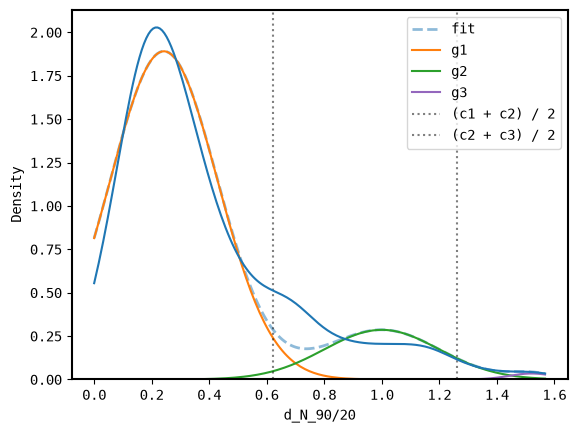

In [59]:
m12, m23, R = guess_3gausians(ds_rollinN_day_max_percentiles_logged, 
                             intensity_parameter='d_N_90/20')

In [60]:
ds_rollinN_day_max_percentiles_logged = log_intensity(ds_rollinN_day_max_percentiles,
                                                    var_to_log='N_int_max')

In [61]:
def guess_3gausians(ds, intensity_parameter='N_90/20'):
    #region sciplot
    a1, a1m, a1M = (1.4, 1.2, 2.0) #a1 = .175 
    c1, c1m, c1M = (1.8, 1.2, 2.0)
    s1, s1m, s1M = (.1, 0, 1)

    # amplitude a, center c, and std s for gaussian 3
    a2, a2m, a2M = (.325, .25, .33)
    c2, c2m, c2M = (2.5, 2.45, 2.6)
    s2, s2m, s2M = (.29, .25, .32)

    # amplitude a, center c, and std s for gaussian 3
    a3, a3m, a3M = (.11, 0.10, 0.12)
    c3, c3m, c3M = (3.0, 2.9, 3.1)
    s3, s3m, s3M = (.3, .2, .4)
    
    A = (a1, c1, s1, a2, c2, s2, a3, c3, s3,)
    B = (a1m, c1m, s1m, a2m, c2m, s2m, a3m, c3m, s3m,)
    C = (a1M, c1M, s1M, a2M, c2M, s2M, a3M, c3M, s3M,)

    logn = ds[intensity_parameter].to_series().dropna()
    mi, ma = logn.describe().T[['min', 'max']]

    # Create figure explicitly
    fig, ax = plt.subplots() 

    m12, m23, R = fit_gaussians(logn, mi, ma, A, B, C,
                                 bw=.25, ax=ax)   
      
    sns.kdeplot(data = logn,
      bw_adjust=.98,
      clip=(ds[intensity_parameter].to_series().min(),
            ds[intensity_parameter].to_series().max()),
            ax=ax)
    
    ax.set_xlabel(r'log($\Delta N_{2.8-5\,\mathrm{nm,\ max}}$)')   
    return m12, m23, R, fig

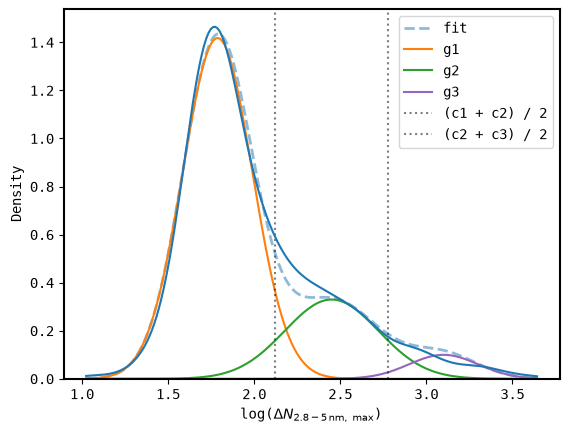

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_S15.jpeg


In [62]:
m12, m23, R, fig = guess_3gausians(ds_rollinN_day_max_percentiles_logged, 
                             intensity_parameter='d_N_int_max')
plt.show()

output_figure = plots_outpath / 'Figure_S15.jpeg'
save_plot(fig, output_figure)

In [63]:
def assign_classes(ds, m12, m23, R, 
                   intensity_parameter):
    bb = np.linspace(0, 100, 21)
    ds  = (ds
        .assign_coords({'g':lambda d:pd.cut(d[intensity_parameter].to_series(),bins=[0,m12,m23,10],
                                            labels=['g1','g2','g3']).to_xarray()})
        .assign_coords({'q':lambda d:d[intensity_parameter].rank(pct=True,dim='day')*100})
        .assign_coords({'qCut':lambda d:pd.cut(d['q'].to_series(), bins=bb,precision=1).to_xarray()}))
    return ds

In [64]:
ds_rollinN_day_max_percentiles_classes = assign_classes(ds_rollinN_day_max_percentiles_logged, m12, m23, R ,
                                                             intensity_parameter='d_N_int_max')

In [65]:
ds_rollinN_day_max_percentiles_classes

<xarray.Dataset> Size: 207MB
Dimensions:        (day: 1374, hour: 96, id: 3, Dp: 64, Dp_interval: 1)
Coordinates:
  * day            (day) datetime64[ns] 11kB 2021-01-01 ... 2024-10-05
    g              (Dp_interval, day) object 11kB nan nan nan ... 'g1' nan nan
    q              (Dp_interval, day) float64 11kB nan nan nan ... 55.36 nan nan
    qCut           (Dp_interval, day) object 11kB nan nan nan ... nan nan
  * hour           (hour) float64 768B 0.0 0.25 0.5 0.75 ... 23.25 23.5 23.75
    t              (day, hour) datetime64[ns] 1MB 2021-01-01 ... NaT
  * id             (id) object 24B 'nais' 'dmps' 'nd'
  * Dp             (Dp) float64 512B 5.012e-10 5.623e-10 ... 6.31e-07 7.079e-07
  * Dp_interval    (Dp_interval) interval[float64, right] 16B (2.82e-09, 5e-09]
    quantile       float64 8B 0.9
Data variables:
    dndlDp         (id, Dp, day, hour) float64 203MB nan nan nan ... nan nan nan
    N              (Dp_interval, day, hour) float64 1MB nan nan nan ... nan nan
    lN             (Dp_interval, day, hour) float64 1MB nan nan nan ... nan nan
    N_int_rollmed  (Dp_interval, day, hour) float64 1MB nan nan nan ... nan nan
    N_int_max      (Dp_interval, day) float64 11kB nan nan nan ... 81.12 nan nan
    N_90perc       (Dp_interval, day) float64 11kB nan nan nan ... 73.89 nan nan
    N_20perc       (Dp_interval, day) float64 11kB nan nan nan ... 21.61 nan nan
    N_90-20        (Dp_interval, day) float64 11kB nan nan nan ... 52.28 nan nan
    N_90/20        (Dp_interval, day) float64 11kB nan nan nan ... 3.419 nan nan
    d_N_int_max    (Dp_interval, day) float64 11kB nan nan nan ... 1.909 nan nan

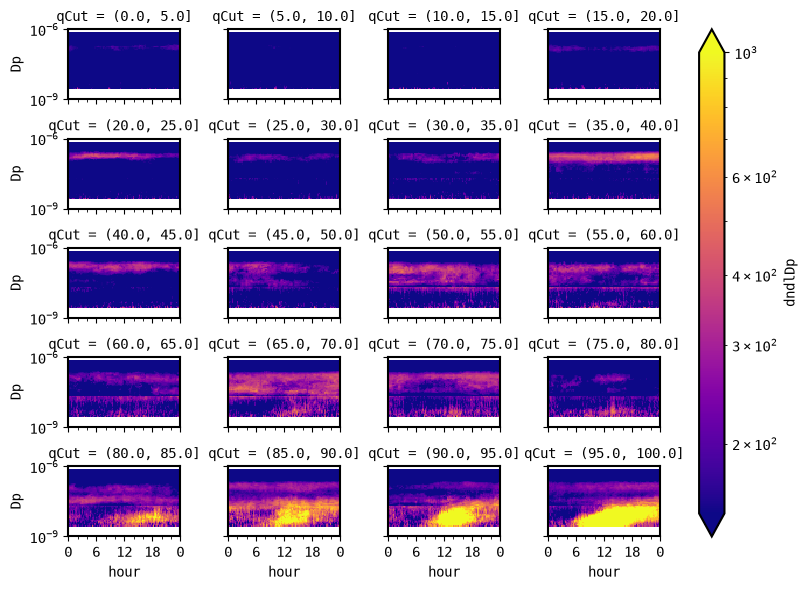

In [66]:
ds_groupby_qcut = (ds_rollinN_day_max_percentiles_classes[['dndlDp','qCut']].groupby('qCut').median().loc[{'id':'nd'}]['dndlDp']
    .plot(
        y='Dp',
        yscale='log',
        norm = mpl.colors.LogNorm(vmin=1.5e2,vmax=1e3),
        cmap = 'plasma',
        col='qCut',
        col_wrap=4,
        size=1.2,
        aspect = 1.6))

yy = 24

for ax in ds_groupby_qcut.axs.flat:
    ax:plt.Axes
    ax.set_box_aspect(1/1.6)    
    ax.set_xlim(0,yy)
    ax.set_ylim(1e-9,1e-6)
    ti = np.arange(0, yy + 1, 6)
    ax.set_xticks(ti)
    ax.set_xticks(np.arange(0, yy+1, 2), minor=True)
    ax.set_xticklabels(np.mod(ti,24))    
plt.show()

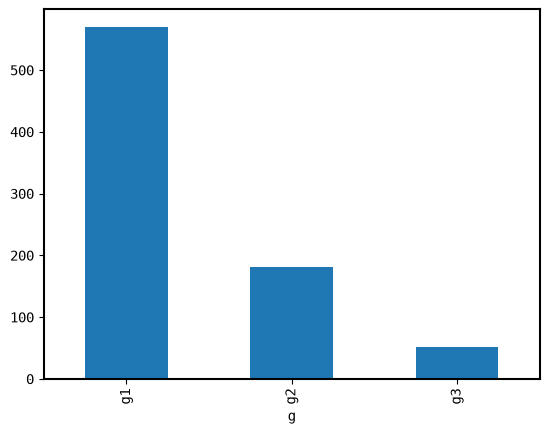

In [67]:
ds_rollinN_day_max_percentiles_classes['g'].to_series().value_counts().plot.bar()
plt.show()

In [68]:
vc = ds_rollinN_day_max_percentiles_classes['g'].to_series().value_counts()

In [69]:
def plot_intensity_classes(ds, g='g1', ncol=5, nrow=10):    
    res = (
        ds[['dndlDp','g']]
        .where(lambda d:d['g']==g,drop=True)
        .pipe(lambda d: d.loc[{'day':d['day'].to_series().sample(
            min(ncol*nrow, d.sizes['day']), replace=False
        ).to_xarray()}])
        .loc[{'id':'nd'}]
        ['dndlDp']
        .plot(
            y='Dp',
            yscale='log',
            norm = mpl.colors.LogNorm(vmin=1.5e2,vmax=10e4),
            cmap = 'plasma',
            col='day',
            col_wrap=5,
            size=1.2,
            aspect = 1.6,
            rasterized = True))
    
    for ax in res.axs.flat:
        ax:plt.Axes
        ax.set_box_aspect(1/1.6)
        yy = 24
        ax.set_xlim(0,yy)
        ax.set_ylim(1e-9,1e-6)
        ti = np.arange(0, yy + 1, 6)
        ax.set_xticks(ti)
        ax.set_xticks(np.arange(0, yy+1, 2), minor=True)
        ax.set_xticklabels(np.mod(ti,24))
    plt.show()

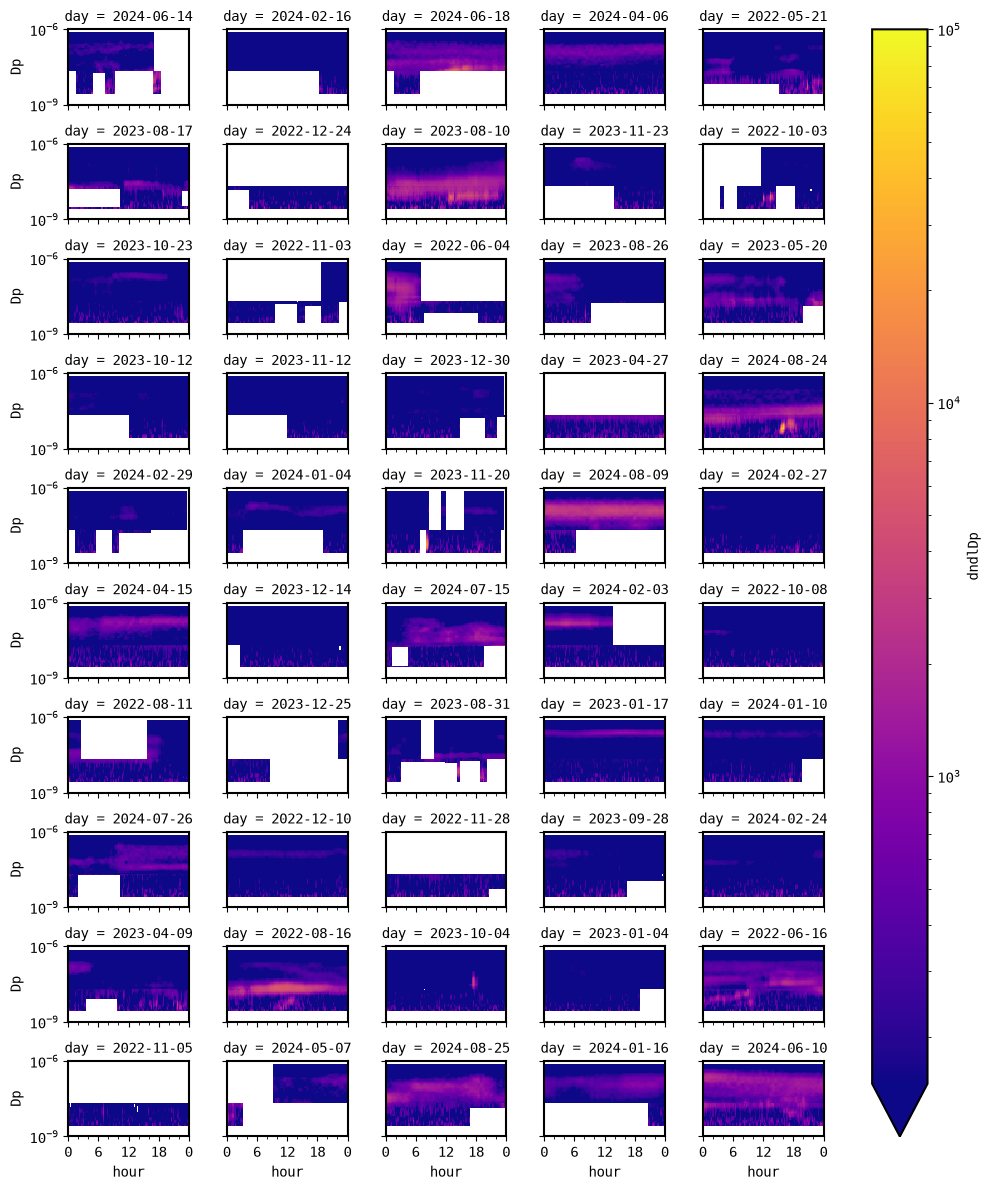

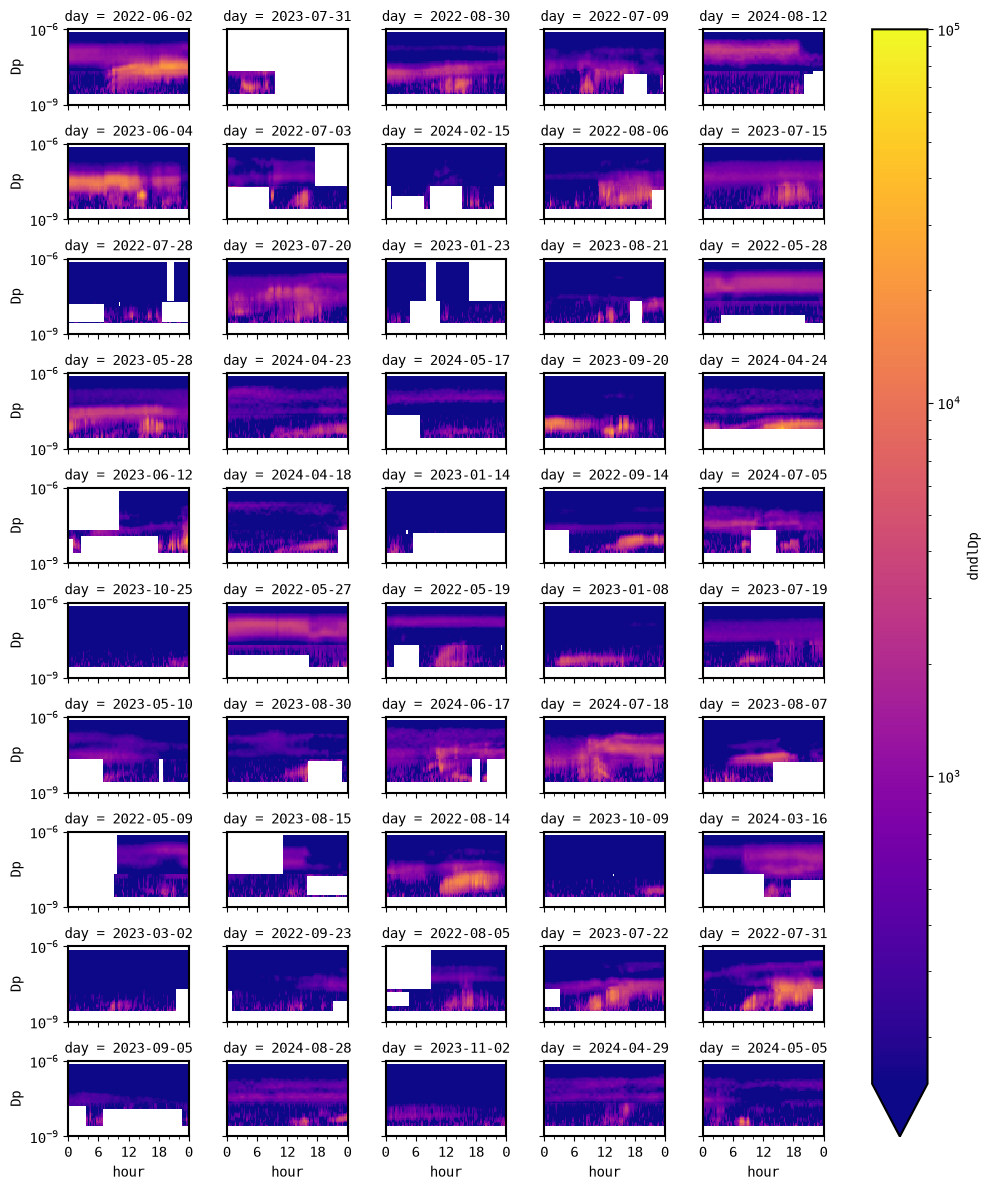

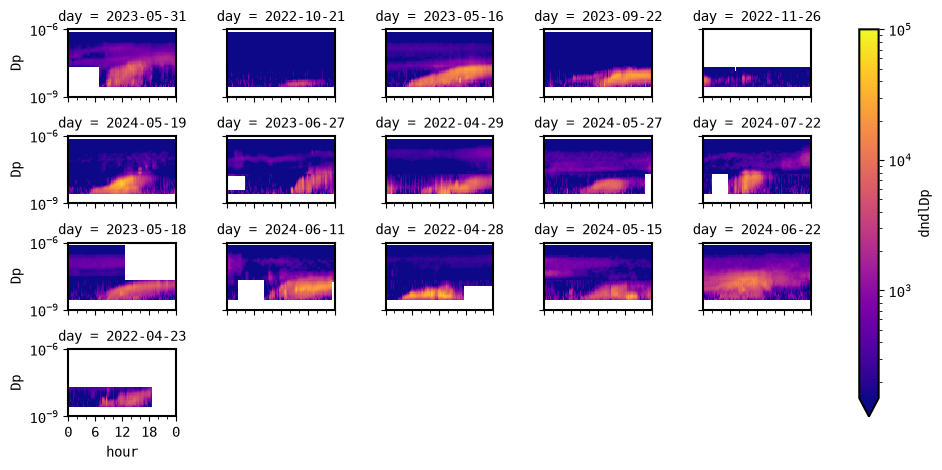

In [70]:
plot_intensity_classes(ds_rollinN_day_max_percentiles_classes, g='g1')
plot_intensity_classes(ds_rollinN_day_max_percentiles_classes, g='g2')
plot_intensity_classes(ds_rollinN_day_max_percentiles_classes, g='g3', ncol=4, nrow=4)


In [71]:
ds_rollinN_day_max_percentiles_classes['Dp_interval'] = ds_rollinN_day_max_percentiles_classes['Dp_interval'].astype(str)
ds_rollinN_day_max_percentiles_classes['qCut'] = ds_rollinN_day_max_percentiles_classes['qCut'].astype(str)

In [72]:
ds_rollinN_day_max_percentiles_classes[['N_int_max', 'dndlDp']].sel({'Dp_interval':'('+str(min_dp)+'e-09, '+str(max_dp)+'e-09]'})
#.to_netcdf(r'C:\Users\DominicHeslinRees\NAIS_work\ZEP_processed_files\nano_ranking\ds_ranking_qs_dnlogdp.nc')

<xarray.Dataset> Size: 204MB
Dimensions:      (day: 1374, id: 3, Dp: 64, hour: 96)
Coordinates:
  * day          (day) datetime64[ns] 11kB 2021-01-01 2021-01-02 ... 2024-10-05
    g            (day) object 11kB nan nan nan nan nan ... 'g2' 'g1' nan nan
    q            (day) float64 11kB nan nan nan nan nan ... 90.77 55.36 nan nan
    qCut         (day) <U13 71kB 'nan' 'nan' 'nan' ... 'nan' 'nan'
  * id           (id) object 24B 'nais' 'dmps' 'nd'
  * Dp           (Dp) float64 512B 5.012e-10 5.623e-10 ... 6.31e-07 7.079e-07
  * hour         (hour) float64 768B 0.0 0.25 0.5 0.75 ... 23.0 23.25 23.5 23.75
    t            (day, hour) datetime64[ns] 1MB 2021-01-01 ... NaT
    Dp_interval  <U17 68B '(2.82e-09, 5e-09]'
    quantile     float64 8B 0.9
Data variables:
    N_int_max    (day) float64 11kB nan nan nan nan nan ... 430.2 81.12 nan nan
    dndlDp       (id, Dp, day, hour) float64 203MB nan nan nan ... nan nan nan

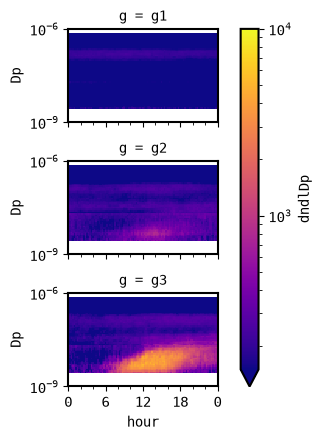

In [73]:
res = (
    ds_rollinN_day_max_percentiles_classes
    [['dndlDp','g']]
    .groupby('g')
    .median()
    .loc[{'id':'nd'}]
    ['dndlDp']
    .plot(
        y='Dp',
        yscale='log',
        norm = mpl.colors.LogNorm(vmin=1.5e2,vmax=1e4),
        cmap = 'plasma',
        row='g',
        size=1.5,
        aspect = 3
    )
)

for ax in res.axs.flat:
    ax:plt.Axes
    ax.set_box_aspect(1/1.6)
    yy = 24 + 0
    ax.set_xlim(0,yy)
    ax.set_ylim(1e-9,1e-6)
    ti = np.arange(0, yy + 1, 6)
    ax.set_xticks(ti)
    ax.set_xticks(np.arange(0, yy+1, 2), minor=True)
    ax.set_xticklabels(np.mod(ti,24))
    
plt.show()

In [74]:
def squeeze_timeseries(ds, intensity_parameter='N_90/20'):
    ds_timeseries = (ds[intensity_parameter].squeeze().to_series())
    return ds_timeseries

In [75]:
ds_timeseries = squeeze_timeseries(ds_rollinN_day_max_percentiles_classes, intensity_parameter='N_90/20')

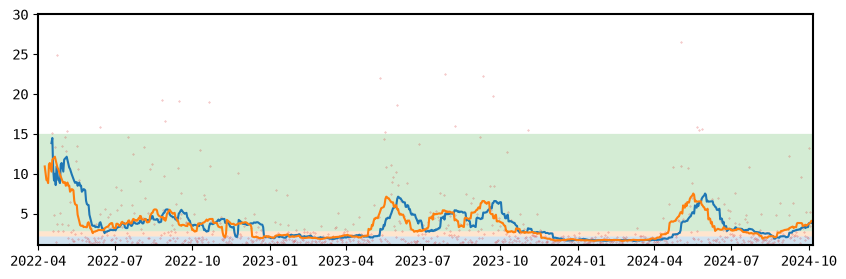

In [76]:
fig, ax = plt.subplots(figsize=(10, 3))
fig:plt.Figure
ax: plt.Axes
    
ax.fill_between(ds_timeseries.index,0,m12,alpha=.2, label='')
ax.fill_between(ds_timeseries.index,m12,m23,alpha=.2)
ax.fill_between(ds_timeseries.index,m23,15,alpha=.2) #where does 15 come from or 5 (originally)

ax.scatter(ds_timeseries.index,ds_timeseries,s=.1,alpha=.5)
ax.plot(ds_timeseries.index, ds_timeseries.rolling('30D').mean())

ax.plot(ds_timeseries.index, ds_timeseries.rolling(window=30, center=True, min_periods=7).mean())
ax.set_xlim(pd.to_datetime('2022-04-01'), pd.to_datetime('2024-10-06'))
ax.set_ylim(1,30)

plt.show()

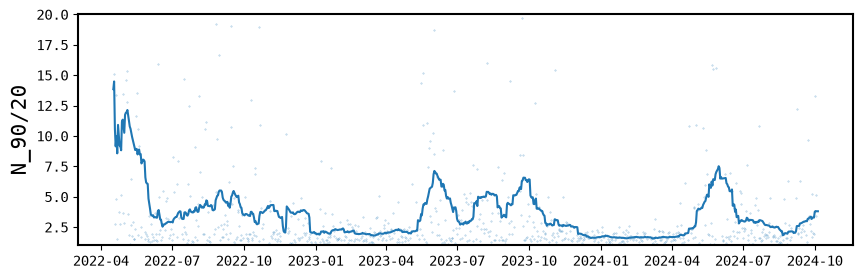

In [77]:
intensity_parameter='N_90/20' #N_int_max 'N_90-20'
ds_timeseries = squeeze_timeseries(ds_rollinN_day_max_percentiles_classes, 
                                   intensity_parameter=intensity_parameter)

fig, ax = plt.subplots(figsize=(10, 3))
fig:plt.Figure
ax: plt.Axes

ax.scatter(ds_timeseries.index,ds_timeseries,s=.1,alpha=.5)
ax.plot(ds_timeseries.index, ds_timeseries.rolling('30D').mean(), 
       label='30 day rolling mean')
ax.set_ylim(1,20)

ax.set_ylabel(str(intensity_parameter), fontsize=15)

plt.show()

In [78]:
df_timeseries = squeeze_timeseries(ds_rollinN_day_max_percentiles_classes, intensity_parameter='N_90/20').to_frame()
df_timeseries = df_timeseries[df_timeseries.index >= '2022-04-17']
print(len(df_timeseries))
stop = str(pd.to_datetime(ds_rollinN_day_max_percentiles_classes.day.values[-1]).date())
date_range = pd.date_range(start='2022-04-17', end=stop, freq='D')
print(len(date_range))

903
903


In [79]:
def quick_timeseries_plot(ds, intensity_parameter='N_90/20', ymax=None): #N_int_max 'N_90-20'
    ds_timeseries = squeeze_timeseries(ds, intensity_parameter=intensity_parameter)

    fig, ax = plt.subplots(figsize=(10, 3))
    fig:plt.Figure
    ax: plt.Axes

    ax.scatter(ds_timeseries.index,ds_timeseries,s=.1,alpha=.5)
    ax.plot(ds_timeseries.index, ds_timeseries.rolling('30D').mean(), 
           label='30 day rolling mean')
    ax.plot(ds_timeseries.index, ds_timeseries.rolling(window=30, center=True, min_periods=7).mean(), 
           label='30 day rolling mean (centred, with 7d min)')
    ax.set_ylim(0,ymax)
    ax.set_ylabel(str(intensity_parameter), fontsize=15)
    ax.legend()
    plt.show()
    return fig

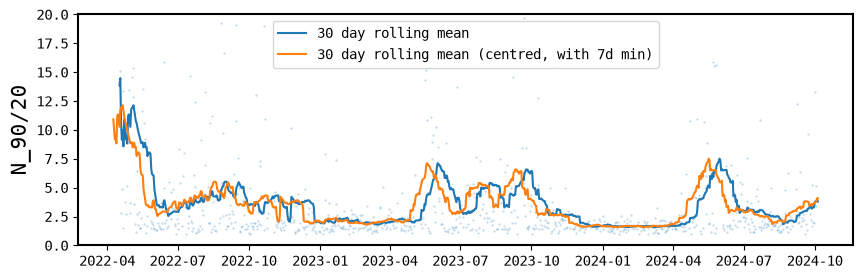

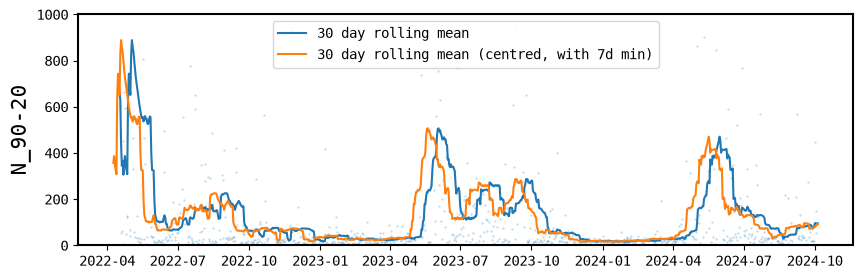

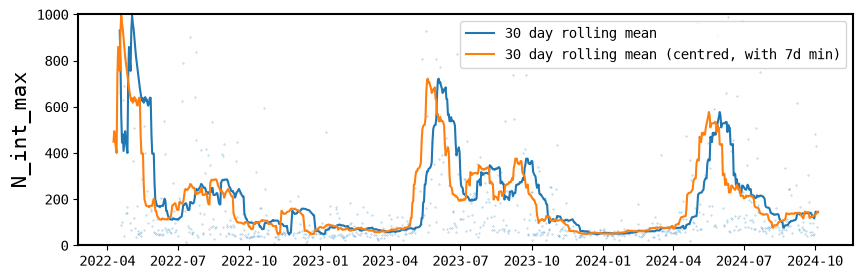

In [80]:
fig = quick_timeseries_plot(ds_rollinN_day_max_percentiles_classes, intensity_parameter='N_90/20', ymax=20)
fig = quick_timeseries_plot(ds_rollinN_day_max_percentiles_classes, intensity_parameter='N_90-20', ymax=1000)
fig = quick_timeseries_plot(ds_rollinN_day_max_percentiles_classes, intensity_parameter='N_int_max', ymax=1000)

In [81]:
def find_peak_time(ds, intensity_parameter='N_int_max', year=None):
    ds_timeseries = squeeze_timeseries(ds, intensity_parameter=intensity_parameter)
    df_timeseries = ds_timeseries.to_frame(name=intensity_parameter).dropna()

    if year is not None:
        df_timeseries = df_timeseries[df_timeseries.index.year == year]
        if df_timeseries.empty:
            raise ValueError(f'No data available for year {year}')
        time_peak = df_timeseries[intensity_parameter].idxmax()
        print(time_peak)
        return time_peak

    yearly_peak_times = df_timeseries.groupby(df_timeseries.index.year)[intensity_parameter].idxmax()
    yearly_peak_values = df_timeseries.loc[yearly_peak_times, intensity_parameter]
    peaks = pd.DataFrame({
        'time_peak': yearly_peak_times,
        'maximum_value': yearly_peak_values.to_numpy()
    }, index=yearly_peak_times.index)
    print(peaks)
    return peaks

In [82]:
yearly_peak_times = find_peak_time(
    ds_rollinN_day_max_percentiles_classes,
    intensity_parameter='N_int_max'
)

      time_peak  maximum_value
day                           
2022 2022-04-28    4397.732901
2023 2023-06-01    2686.022427
2024 2024-05-19    3043.189576


In [83]:
def if_folder_doesnt_exist_create(directory):
    if not os.path.exists(directory):
        print("make directory: "+str(directory))
        os.makedirs(directory)
        
def save_df(df, path, name='', index=True, float_format=None, data_format='.dat'):
    print("Save as: "+str(path+'\\'+name+str(data_format)))
    if_folder_doesnt_exist_create(path)
    df.to_csv(path+'\\'+name+str(data_format), index=index, float_format=float_format)

In [84]:
df_timeseries_90ratio20 = squeeze_timeseries(ds_rollinN_day_max_percentiles_classes, 
                                   intensity_parameter='N_90/20')
df_timeseries_90minus20 = squeeze_timeseries(ds_rollinN_day_max_percentiles_classes, 
                                   intensity_parameter='N_90-20')
df_timeseries_NintMax = squeeze_timeseries(ds_rollinN_day_max_percentiles_classes, 
                                    intensity_parameter='N_int_max')

nanorank_save_path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Nano_ranking'

save_df(df_timeseries_90ratio20, nanorank_save_path,
        name='N_90ratio20')
save_df(df_timeseries_90minus20, nanorank_save_path,
        name='N_90-20')
save_df(df_timeseries_NintMax, nanorank_save_path,
        name='N_int_max')

df_g_timeseries = squeeze_timeseries(ds_rollinN_day_max_percentiles_classes, intensity_parameter='g')
save_df(df_g_timeseries, nanorank_save_path, name='g_intensity_classification')

df_timeseries_NintMax = squeeze_timeseries(ds_rollinN_day_max_percentiles_classes, intensity_parameter='N_int_max')

ds_rollinN_day_max_percentiles_classes_str = ds_rollinN_day_max_percentiles_classes.drop('Dp_interval').assign_coords({'qCut':lambda d:d['qCut'].astype('str')}).sel({'Dp_interval':0})

Save as: C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Nano_ranking\N_90ratio20.dat
Save as: C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Nano_ranking\N_90-20.dat
Save as: C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Nano_ranking\N_int_max.dat
Save as: C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Nano_ranking\g_intensity_classification.dat


C:\Users\Dell\AppData\Local\Temp\ipykernel_19948\2933722942.py:22: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_rollinN_day_max_percentiles_classes_str = ds_rollinN_day_max_percentiles_classes.drop('Dp_interval').assign_coords({'qCut':lambda d:d['qCut'].astype('str')}).sel({'Dp_interval':0})


In [85]:
ds_rollinN_day_max_percentiles_classes_str

<xarray.Dataset> Size: 207MB
Dimensions:        (day: 1374, hour: 96, id: 3, Dp: 64)
Coordinates:
  * day            (day) datetime64[ns] 11kB 2021-01-01 ... 2024-10-05
    g              (day) object 11kB nan nan nan nan nan ... 'g2' 'g1' nan nan
    q              (day) float64 11kB nan nan nan nan ... 90.77 55.36 nan nan
    qCut           (day) <U13 71kB 'nan' 'nan' 'nan' ... 'nan' 'nan'
  * hour           (hour) float64 768B 0.0 0.25 0.5 0.75 ... 23.25 23.5 23.75
    t              (day, hour) datetime64[ns] 1MB 2021-01-01 ... NaT
  * id             (id) object 24B 'nais' 'dmps' 'nd'
  * Dp             (Dp) float64 512B 5.012e-10 5.623e-10 ... 6.31e-07 7.079e-07
    quantile       float64 8B 0.9
Data variables:
    dndlDp         (id, Dp, day, hour) float64 203MB nan nan nan ... nan nan nan
    N              (day, hour) float64 1MB nan nan nan nan ... nan nan nan nan
    lN             (day, hour) float64 1MB nan nan nan nan ... nan nan nan nan
    N_int_rollmed  (day, hour) float64 1MB nan nan nan nan ... nan nan nan nan
    N_int_max      (day) float64 11kB nan nan nan nan ... 430.2 81.12 nan nan
    N_90perc       (day) float64 11kB nan nan nan nan ... 183.0 73.89 nan nan
    N_20perc       (day) float64 11kB nan nan nan nan nan ... 35.3 21.61 nan nan
    N_90-20        (day) float64 11kB nan nan nan nan ... 147.7 52.28 nan nan
    N_90/20        (day) float64 11kB nan nan nan nan ... 5.184 3.419 nan nan
    d_N_int_max    (day) float64 11kB nan nan nan nan ... 2.634 1.909 nan nan

In [86]:
ds_timeseries = squeeze_timeseries(ds_rollinN_day_max_percentiles_classes)

In [87]:
classification_load_path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\DalMaso_classification'

ZEP_class = pd.read_csv(classification_load_path+'\\'+'ZEP_class_DalMaso.txt', parse_dates=True, index_col=0)
ZEP_class.index.name = 'day'

replacement_map = {'A': 'Class Ia', 'B': 'Class Ib', 'C': 'Class II', 'D': 'Undefined', 'E': 'Non-event'}
inv_replacement_map = {v: k for k, v in replacement_map.items()}


def set_dalmaso_col(df, class_type='Class Ia', condition=1):
    df.loc[df[class_type] == condition, ['DALMASO']] = inv_replacement_map[class_type]
    return df


ZEP_class = set_dalmaso_col(ZEP_class, class_type='Class Ia', condition=1)
ZEP_class = set_dalmaso_col(ZEP_class, class_type='Class Ib', condition=1)
ZEP_class = set_dalmaso_col(ZEP_class, class_type='Class II', condition=1)
ZEP_class = set_dalmaso_col(ZEP_class, class_type='Undefined', condition=1)
ZEP_class = set_dalmaso_col(ZEP_class, class_type='Non-event', condition=1)

ds_ZEP_class = ZEP_class[['DALMASO']].to_xarray()
ds_rollinN_day_max_percentiles_classes_dalmaso = xr.merge([ds_rollinN_day_max_percentiles_classes_str, ds_ZEP_class])


ds_rollinN_day_max_percentiles_classes_ = (ds_rollinN_day_max_percentiles_classes_dalmaso['DALMASO'] == 'A') | (ds_rollinN_day_max_percentiles_classes_dalmaso['DALMASO'] == 'B') | (ds_rollinN_day_max_percentiles_classes_dalmaso['DALMASO'] == 'C') | (ds_rollinN_day_max_percentiles_classes_dalmaso['DALMASO'] == 'D') | (ds_rollinN_day_max_percentiles_classes_dalmaso['DALMASO'] == 'E')
classifible_days= (ds_rollinN_day_max_percentiles_classes_)
classifiable_data = ds_rollinN_day_max_percentiles_classes_.sel({'day': classifible_days})

C:\Users\Dell\AppData\Local\Temp\ipykernel_19948\4142124264.py:22: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'day' ('day',) The recommendation is to set join explicitly for this case.
  ds_rollinN_day_max_percentiles_classes_dalmaso = xr.merge([ds_rollinN_day_max_percentiles_classes_str, ds_ZEP_class])


In [88]:
ds_rollinN_day_max_percentiles_classes_dalmaso

<xarray.Dataset> Size: 207MB
Dimensions:        (day: 1374, hour: 96, Dp: 64, id: 3)
Coordinates:
  * day            (day) datetime64[ns] 11kB 2021-01-01 ... 2024-10-05
    g              (day) object 11kB nan nan nan nan nan ... 'g2' 'g1' nan nan
    q              (day) float64 11kB nan nan nan nan ... 90.77 55.36 nan nan
    qCut           (day) <U13 71kB 'nan' 'nan' 'nan' ... 'nan' 'nan'
  * hour           (hour) float64 768B 0.0 0.25 0.5 0.75 ... 23.25 23.5 23.75
    t              (day, hour) datetime64[ns] 1MB 2021-01-01 ... NaT
  * Dp             (Dp) float64 512B 5.012e-10 5.623e-10 ... 6.31e-07 7.079e-07
  * id             (id) object 24B 'nais' 'dmps' 'nd'
    quantile       float64 8B 0.9
Data variables:
    dndlDp         (id, Dp, day, hour) float64 203MB nan nan nan ... nan nan nan
    N              (day, hour) float64 1MB nan nan nan nan ... nan nan nan nan
    lN             (day, hour) float64 1MB nan nan nan nan ... nan nan nan nan
    N_int_rollmed  (day, hour) float64 1MB nan nan nan nan ... nan nan nan nan
    N_int_max      (day) float64 11kB nan nan nan nan ... 430.2 81.12 nan nan
    N_90perc       (day) float64 11kB nan nan nan nan ... 183.0 73.89 nan nan
    N_20perc       (day) float64 11kB nan nan nan nan nan ... 35.3 21.61 nan nan
    N_90-20        (day) float64 11kB nan nan nan nan ... 147.7 52.28 nan nan
    N_90/20        (day) float64 11kB nan nan nan nan ... 5.184 3.419 nan nan
    d_N_int_max    (day) float64 11kB nan nan nan nan ... 2.634 1.909 nan nan
    DALMASO        (day) object 11kB nan nan nan nan nan ... 'A' 'D' 'D' 'D' nan

In [89]:
stat = ds_rollinN_day_max_percentiles_classes_dalmaso.copy()
classifiable_data = ds_rollinN_day_max_percentiles_classes_dalmaso.copy()

col_colors = {'DJF': '#2B7E7E',
    'MAM': '#39A939',
    'JJA': '#D34747',
    'SON': '#D38647'}

par = ['N_int_max','N_90-20','N_90/20'] # Create separate plots for each variable

def produce_classification_comparison(classifiable_data, variable):
    title = "ZEP"
    percentiles = classifiable_data[variable].to_series().dropna().apply(lambda x: percentileofscore(classifiable_data[variable].to_series().dropna(), x))
    df = pd.DataFrame({'Values': classifiable_data[variable].to_series(),
                       'perc_rank': percentiles, 
                       'DALMASO': classifiable_data['DALMASO'].to_series()})
    replacement_map = {'A': 'Class Ia', 'B': 'Class Ib', 'C': 'Class II', 'D': 'Undefined', 'E': 'Non-event'}
    df['DALMASO'] = df['DALMASO'].replace(replacement_map)
    sns.histplot(
        data=df,
        x='perc_rank',
        hue='DALMASO',
        multiple='stack',
        bins=np.arange(0, 101, 5),
        palette='RdYlBu_r',
        hue_order=pd.Series(['Class Ia', 'Class Ib', 'Class II', 'Undefined', 'Non-event'])[::-1],
        alpha=1
    )
    ax:plt.Axes = plt.gca()
    ax.set_xlim(0,100)
    ax.set_box_aspect(1/1.6)
    ax.set_title('Nano-ranking vs. Dal Maso classification\n$\Delta N_{2.8-5\mathrm{nm}}$ (intensity parameter)')
    ax.set_xlabel('Percentile ranking [-]')
    f:plt.Figure = plt.gcf()
    a_ = 5
    f.set_size_inches(a_+1,a_/1.6)
    plt.show()
    return f

<>:32: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:32: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_19948\4055519344.py:32: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax.set_title('Nano-ranking vs. Dal Maso classification\n$\Delta N_{2.8-5\mathrm{nm}}$ (intensity parameter)')


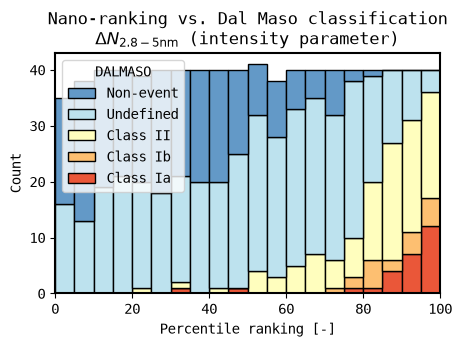

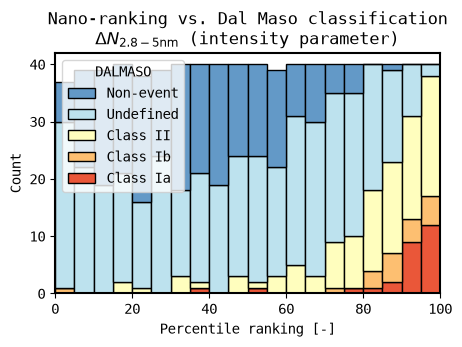

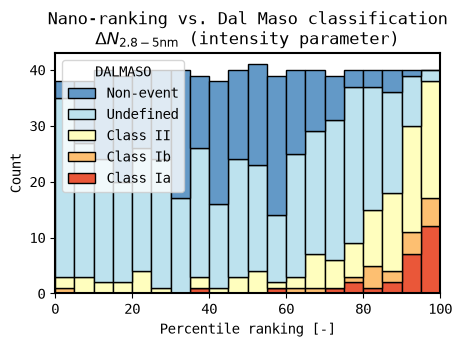

In [90]:
for variable in par:
    produce_classification_comparison(classifiable_data, variable)

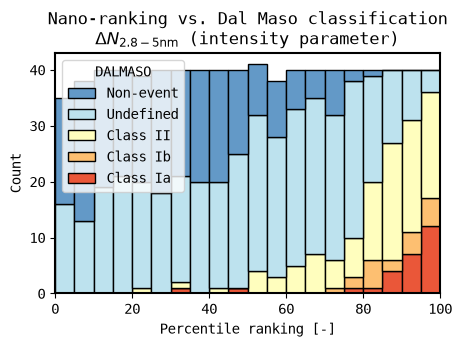

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_S14.jpeg


In [91]:
fig = produce_classification_comparison(classifiable_data, variable='N_int_max')
output_figure = plots_outpath / 'Figure_S14.jpeg'
save_plot(fig, output_figure)

In [92]:
dalmaso_variables = ds_rollinN_day_max_percentiles_classes_dalmaso["DALMASO"]
unique_vals = np.array(list(set(ds_rollinN_day_max_percentiles_classes_dalmaso["DALMASO"].values.ravel())))
print(unique_vals)

['C' 'E' 'B' 'nan' 'D' 'A' 'nan']


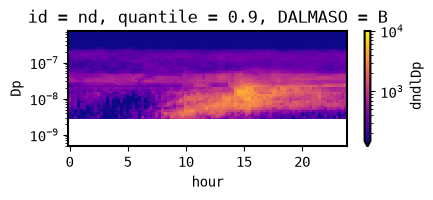

In [93]:
data_dalmaso = ds_rollinN_day_max_percentiles_classes_dalmaso.copy()
replacement_map = {'A': 'Class Ia', 'B': 'Class Ib', 'C': 'Class II', 'D': 'Undefined', 'E': 'Non-event'}

data_dalmaso[['dndlDp','DALMASO']].groupby('DALMASO').median().loc[{'id':'nd'}]['dndlDp'][1].plot(y='Dp',
        yscale='log',
        norm = mpl.colors.LogNorm(vmin=1.5e2,vmax=1e4),
        cmap = 'plasma',
        size=1.5,
        aspect = 3
    )

subset = data_dalmaso.where(data_dalmaso["DALMASO"] == "A", drop=True)


def create_colourbar(cax, vmin=10**(-1), vmax=10**4, cmap='jet', extend='both', 
                     colourbar_label=r'dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', fontsize=12,
                     scientific_notation=True, log_scale=True, orientation='vertical', labels=None):
    if log_scale == True:
        norm = LogNorm(vmin, vmax)
    if log_scale == False:
        norm=Normalize(vmin, vmax)
    fmt = None
    if cmap is None:
        cmap = mpl.colormaps['magma']
    if cmap is not None:
        cmap = mpl.colormaps[cmap] if isinstance(cmap, str) else cmap
    if scientific_notation == True:
        fmt = ticker.ScalarFormatter(useMathText=True)
        fmt.set_powerlimits((-2, 4)) 
        
    print(norm)
        
    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation=orientation)
    cb.set_label(colourbar_label, fontsize=fontsize)
    cb.ax.tick_params(labelsize=fontsize)
    cb.ax.yaxis.set_offset_position('left')    
    cb.ax.yaxis.get_offset_text().set_fontsize(fontsize)    
    cb.update_ticks()
    
    if labels is not None:
        cb.set_ticklabels(labels)
        locs=[vmin, vmax]
        cb.set_ticks(locs)
        
    return cb 

In [94]:
len(data_dalmaso.where(data_dalmaso["DALMASO"] == "E", drop=True).DALMASO.values)

253

In [95]:
replacement_map = {'A': 'Class Ia', 'B': 'Class Ib', 'C': 'Class II', 'D': 'Undefined', 'E': 'Non-event'}
classIa = data_dalmaso.where(data_dalmaso["DALMASO"] == "A", drop=True)[['dndlDp','DALMASO']].groupby('DALMASO').median().loc[{'id':'nd'}]['dndlDp']
classIb = data_dalmaso.where(data_dalmaso["DALMASO"] == "B", drop=True)[['dndlDp','DALMASO']].groupby('DALMASO').median().loc[{'id':'nd'}]['dndlDp']
classII = data_dalmaso.where(data_dalmaso["DALMASO"] == "C", drop=True)[['dndlDp','DALMASO']].groupby('DALMASO').median().loc[{'id':'nd'}]['dndlDp']
Undefined = data_dalmaso.where(data_dalmaso["DALMASO"] == "D", drop=True)[['dndlDp','DALMASO']].groupby('DALMASO').median().loc[{'id':'nd'}]['dndlDp']
Nonevent = data_dalmaso.where(data_dalmaso["DALMASO"] == "E", drop=True)[['dndlDp','DALMASO']].groupby('DALMASO').median().loc[{'id':'nd'}]['dndlDp']

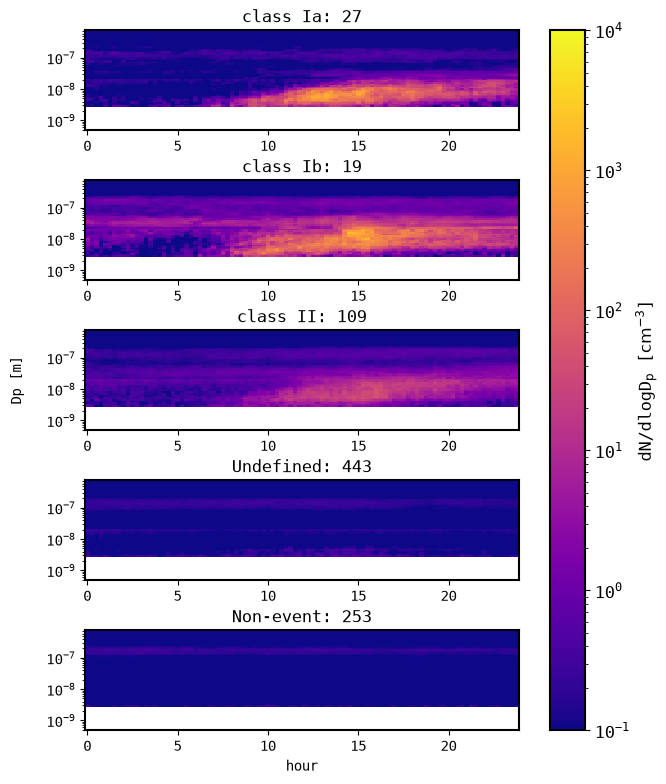

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_13.jpeg


In [96]:
fig = plt.figure(figsize=(5, 7))
gs = gridspec.GridSpec(ncols=16, nrows=5, hspace = .5, wspace=14, top = 1,
                           bottom = 0, left = 0, right = 1)

#first 2 rows - the 0 - 3 row 
ax1 = fig.add_subplot(gs[0, 0:14]) 
number_classIa = len(data_dalmaso.where(data_dalmaso["DALMASO"] == "A", drop=True).DALMASO.values)
classIa.plot(y='Dp',
        yscale='log',
        norm = mpl.colors.LogNorm(vmin=1.5e2,vmax=1e4),
        cmap = 'plasma', add_colorbar=False, ax=ax1) 
ax1.set_title("class Ia: "+str(number_classIa))

number_classIb = len(data_dalmaso.where(data_dalmaso["DALMASO"] == "B", drop=True).DALMASO.values)

ax2 = fig.add_subplot(gs[1, 0:14]) 
classIb.plot(y='Dp',
        yscale='log',
        norm = mpl.colors.LogNorm(vmin=1.5e2,vmax=1e4),
        cmap = 'plasma', add_colorbar=False, ax=ax2) 
ax2.set_title("class Ib: "+str(number_classIb))

number_classII = len(data_dalmaso.where(data_dalmaso["DALMASO"] == "C", drop=True).DALMASO.values)

ax3 = fig.add_subplot(gs[2, 0:14]) 
classII.plot(y='Dp',
        yscale='log',
        norm = mpl.colors.LogNorm(vmin=1.5e2,vmax=1e4),
        cmap = 'plasma',add_colorbar=False, ax=ax3) 
ax3.set_title("class II: "+str(number_classII))

number_classU = len(data_dalmaso.where(data_dalmaso["DALMASO"] == "D", drop=True).DALMASO.values)
ax4 = fig.add_subplot(gs[3, 0:14]) 
Undefined.plot(y='Dp',
        yscale='log',
        norm = mpl.colors.LogNorm(vmin=1.5e2,vmax=1e4),
        cmap = 'plasma',add_colorbar=False, ax=ax4) 
ax4.set_title("Undefined: "+str(number_classU))
number_classNE = len(data_dalmaso.where(data_dalmaso["DALMASO"] == "E", drop=True).DALMASO.values)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel('')
    ax.set_ylabel('')
    

ax5 = fig.add_subplot(gs[4, 0:14]) 
number_classNE = len(data_dalmaso.where(data_dalmaso["DALMASO"] == "E", drop=True).DALMASO.values)
Nonevent.plot(y='Dp',
        yscale='log',
        norm = mpl.colors.LogNorm(vmin=1.5e2,vmax=1e4),
        cmap = 'plasma',add_colorbar=False, ax=ax5) 
ax5.set_title("Non-event: "+str(number_classNE))
ax5.set_ylabel('')

cax = fig.add_subplot(gs[0:5, 14:16])
create_colourbar(cax, cmap = 'plasma')

fig.text(-0.15, 0.5, 'Dp [m]', va='center', rotation='vertical')

plt.show()


output_figure = plots_outpath / 'Figure_13.jpeg'
save_plot(fig, output_figure)

In [97]:
ZEP_class = pd.read_csv(classification_load_path+'\ZEP_class_DalMaso.txt')

<>:1: SyntaxWarning: "\Z" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\Z"? A raw string is also an option.
<>:1: SyntaxWarning: "\Z" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\Z"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_19948\3361622272.py:1: SyntaxWarning: "\Z" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\Z"? A raw string is also an option.
  ZEP_class = pd.read_csv(classification_load_path+'\ZEP_class_DalMaso.txt')


In [98]:
ZEP_class.head(2)

,datetime,Class Ia,Class Ib,Class II,Undefined,Non-event,too little data,maso comments,windblown seen in DMPS,month,year,month_year
0,2022-04-17,NaN,NaN,NaN,NaN,NaN,1.0,could be class I,NaN,4,2022,16
1,2022-04-18,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,4,2022,16


In [99]:
ZEP_class['Class Ia'] = ZEP_class['Class Ia'].replace(1, 'Ia')
ZEP_class['Class Ib'] = ZEP_class['Class Ib'].replace(1, 'Ib')
ZEP_class['Class II'] = ZEP_class['Class II'].replace(1, 'II')
ZEP_class['Undefined'] = ZEP_class['Undefined'].replace(1, 'U')
ZEP_class['Non-event'] = ZEP_class['Non-event'].replace(1, 'NG')

ZEP_class['Class'] = ZEP_class[['Class Ia','Class Ib','Class II',
                                'Undefined','Non-event']].bfill(axis=1).iloc[:,0]

#ZEP_class['datetime'] = pd.to_datetime(ZEP_class['datetime'].values)
dict_date_to_class = dict(zip(ZEP_class['datetime'], ZEP_class['Class']))
print(dict_date_to_class)


dates = [*dict_date_to_class.keys()]
nano_dates = ds_rollinN_day_max_percentiles_classes.day.values
remaining_dates = list(set(nano_dates) - set(dates))
print(remaining_dates)
remaining_dates = [str(pd.to_datetime(x).date()) for x in remaining_dates]
remaining_dates_dict = dict(zip(remaining_dates, len(remaining_dates)*[np.nan]))

dict_date_to_class = {**dict_date_to_class, **remaining_dates_dict}

{'2022-04-17': nan, '2022-04-18': 'II', '2022-04-19': 'U', '2022-04-20': 'U', '2022-04-21': 'Ia', '2022-04-22': 'U', '2022-04-23': 'II', '2022-04-24': 'Ia', '2022-04-25': 'NG', '2022-04-26': 'U', '2022-04-27': 'U', '2022-04-28': 'II', '2022-04-29': 'II', '2022-04-30': 'U', '2022-05-01': 'U', '2022-05-02': 'II', '2022-05-03': 'Ia', '2022-05-04': 'II', '2022-05-05': 'Ia', '2022-05-06': 'U', '2022-05-07': 'U', '2022-05-08': 'U', '2022-05-09': 'U', '2022-05-10': 'U', '2022-05-11': 'NG', '2022-05-12': 'NG', '2022-05-13': 'U', '2022-05-14': 'NG', '2022-05-15': 'NG', '2022-05-16': 'II', '2022-05-17': 'Ib', '2022-05-18': 'U', '2022-05-19': 'II', '2022-05-20': 'II', '2022-05-21': 'U', '2022-05-22': 'II', '2022-05-23': 'U', '2022-05-24': 'NG', '2022-05-25': 'NG', '2022-05-26': 'NG', '2022-05-27': 'NG', '2022-05-28': 'U', '2022-05-29': 'NG', '2022-05-30': 'II', '2022-05-31': 'U', '2022-06-01': 'NG', '2022-06-02': 'Ia', '2022-06-03': 'NG', '2022-06-04': 'U', '2022-06-05': 'II', '2022-06-06': 'U', 

In [100]:
ds_rollinN_day_max_percentiles_classes = ds_rollinN_day_max_percentiles_classes.assign_coords(day=pd.to_datetime(ds_rollinN_day_max_percentiles_classes.day.values).strftime("%Y-%m-%d"))
ds_rollinN_day_max_percentiles_classes = ds_rollinN_day_max_percentiles_classes.assign_coords(day=[t for t in ds_rollinN_day_max_percentiles_classes.day.values])

In [101]:
data = ds_rollinN_day_max_percentiles_classes.assign_coords(Class=("day", [dict_date_to_class[t] for t in ds_rollinN_day_max_percentiles_classes.day.values]))